Found 17 energy files between 1e+03 and 5e+04 GeV:
  E=1.12202e3 (1.122e+03 GeV)
  E=1.41254e3 (1.413e+03 GeV)
  E=1.77828e3 (1.778e+03 GeV)
  E=2.23872e3 (2.239e+03 GeV)
  E=2.81838e3 (2.818e+03 GeV)
  E=3.54813e3 (3.548e+03 GeV)
  E=4.46684e3 (4.467e+03 GeV)
  E=5.62341e3 (5.623e+03 GeV)
  E=7.07946e3 (7.079e+03 GeV)
  E=8.91251e3 (8.913e+03 GeV)
  E=1.12202e4 (1.122e+04 GeV)
  E=1.41254e4 (1.413e+04 GeV)
  E=1.77828e4 (1.778e+04 GeV)
  E=2.23872e4 (2.239e+04 GeV)
  E=2.81838e4 (2.818e+04 GeV)
  E=3.54813e4 (3.548e+04 GeV)
  E=4.46684e4 (4.467e+04 GeV)
  Loaded E=1.12202e3 seed=1: 31798 rows
  Loaded E=1.12202e3 seed=2: 24236 rows
  Loaded E=1.12202e3 seed=3: 24272 rows
  Loaded E=1.41254e3 seed=1: 32105 rows
  Loaded E=1.41254e3 seed=2: 24236 rows
  Loaded E=1.41254e3 seed=3: 24344 rows
  Loaded E=1.77828e3 seed=1: 32302 rows
  Loaded E=1.77828e3 seed=2: 24344 rows
  Loaded E=1.77828e3 seed=3: 24308 rows
  Loaded E=2.23872e3 seed=1: 32105 rows
  Loaded E=2.23872e3 seed=2: 24236 rows

  Loaded E=4.46684e3 seed=3: 24632 rows
  Loaded E=5.62341e3 seed=1: 31228 rows
  Loaded E=5.62341e3 seed=2: 24380 rows
  Loaded E=5.62341e3 seed=3: 24560 rows
  Loaded E=7.07946e3 seed=1: 31264 rows
  Loaded E=7.07946e3 seed=2: 25028 rows
  Loaded E=7.07946e3 seed=3: 24884 rows
  Loaded E=8.91251e3 seed=1: 31408 rows
  Loaded E=8.91251e3 seed=2: 24992 rows
  Loaded E=8.91251e3 seed=3: 24740 rows
  Loaded E=1.12202e4 seed=1: 31120 rows
  Loaded E=1.12202e4 seed=2: 0 rows
  Loaded E=1.12202e4 seed=3: 0 rows
  Loaded E=1.41254e4 seed=1: 31120 rows
  Loaded E=1.41254e4 seed=2: 0 rows
  Loaded E=1.41254e4 seed=3: 0 rows
  Loaded E=1.77828e4 seed=1: 31120 rows
  Loaded E=1.77828e4 seed=2: 0 rows
  Loaded E=1.77828e4 seed=3: 0 rows
  Loaded E=2.23872e4 seed=1: 31118 rows
  Loaded E=2.23872e4 seed=2: 0 rows
  Loaded E=2.23872e4 seed=3: 0 rows
  Loaded E=2.81838e4 seed=1: 31119 rows
  Loaded E=2.81838e4 seed=2: 0 rows
  Loaded E=2.81838e4 seed=3: 0 rows
  Loaded E=3.54813e4 seed=1: 31116 rows


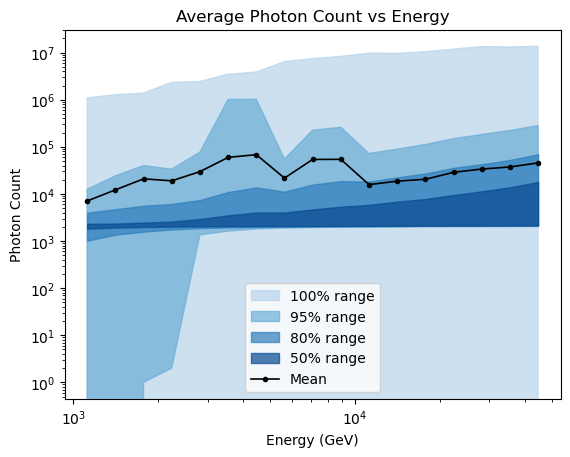

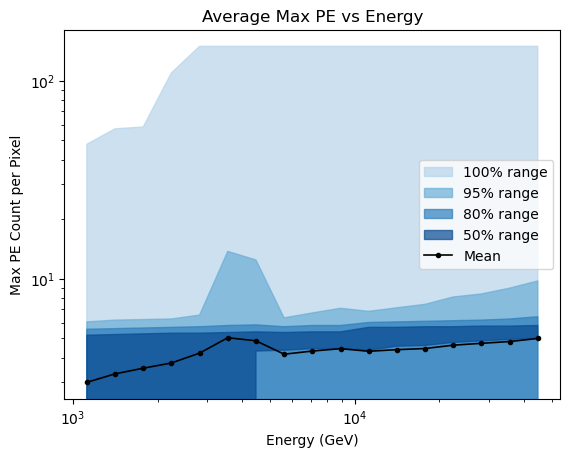

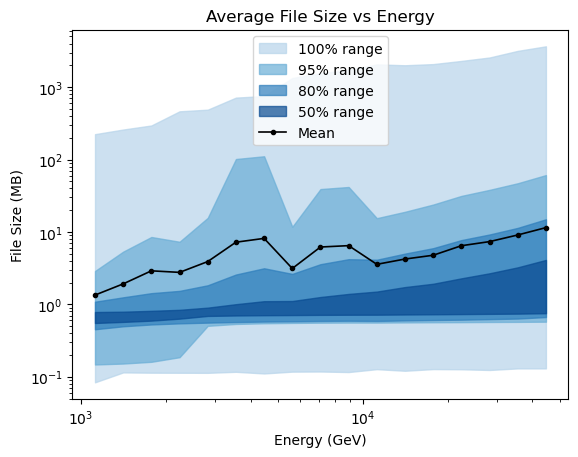

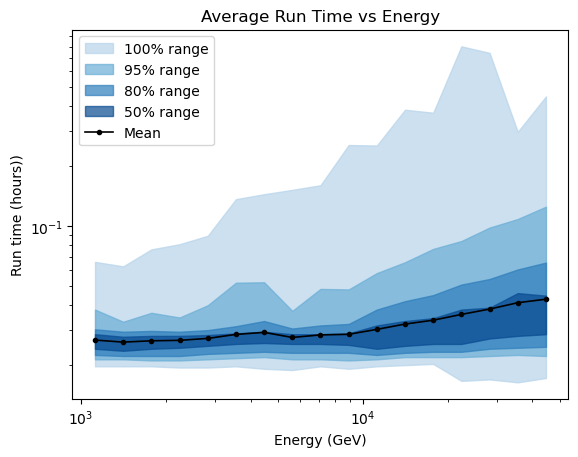

1.7399147954309993 TB 6005.4783989980515 photon per MB


In [ ]:
#Extract data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import os
import sys
import math

# ── Configuration ─────────────────────────────────────────────────────────────
PE_THRESHOLD = 20
#N_BOOTSTRAP = 1000
#CI_LEVEL = 0.99
E_MIN_GEV = 1e3
E_MAX_GEV = 1e4
SEEDS = [1,2,3]
PID = 13
RADIUS = 5
BASE_DIR = "/scratch/general/vast/u1520754/muon_sim_chain_tree"


# ── Helper functions ─────────────────────────────────────────────────────────
def load_scan(csv_path: str) -> pd.DataFrame:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    n_missing = (df["file_found"] == 0).sum()
    if n_missing > 0:
        print(f"  WARNING: {n_missing} rows had file_found=0 and will be dropped.")
        index = (df["file_found"] == 0)
        """print("zenith",set(df["zen"][index]))
        print("azimuth",set(df["az"][index]))
        print("height",set(df["height"][index]))"""
    df = df[df["file_found"] == 1].copy()
    df["r"] = np.sqrt(df["tel_x"]**2 + df["tel_z"]**2).round(4)
    df["detected"] = (df["max_pe"] >= PE_THRESHOLD).astype(float)
    return df

def slant_depth(zem, obs_height, zenith_rad):
    theta = np.pi - zenith_rad
    arg = (obs_height / zem) * np.sin(theta)
    arg = np.clip(arg, -1.0, 1.0)
    beta = np.where(np.isfinite(arg), np.arcsin(arg), 0.0)
    beta = np.clip(beta, 0.0, np.pi/2)
    #beta = np.clip(np.arcsin((obs_height / zem) * np.sin(theta)), 0, np.pi/2)
    alpha = np.pi - theta - beta
    s = zem * np.sin(alpha) / np.sin(theta)
    return np.clip(s, 0, np.inf)
def incidence_angle(Zenith_deg, Azimuth_deg):
    Zenith = Zenith_deg
    Azimuth = Azimuth_deg
    cos_Zenith = np.cos(np.radians(Zenith))
    cos_Azimuth = np.cos(np.radians(Azimuth - 180))
    cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
    Incidence = np.degrees(np.arccos(cos_Incidence))
    return Incidence


import re
import os

def get_available_energies(base_dir, pid, radius, e_min_GeV, e_max_GeV):
    """
    Scan BASE_DIR for folders matching the given PID and RADIUS,
    extract energy values, and filter by [e_min_GeV, e_max_GeV].
    Returns sorted list of (energy_GeV, energy_str) tuples.
    """
    pattern = re.compile(
        rf"Muon_pid{pid}_E([0-9]+\.?[0-9]*e[+-]?[0-9]+)_R{radius}$"
    )
    found = {}
    for name in os.listdir(base_dir):
        m = pattern.match(name)
        if m:
            energy_str = m.group(1)
            energy_val = float(energy_str)
            if e_min_GeV <= energy_val <= e_max_GeV:
                found[energy_val] = energy_str

    return sorted(found.items())  # sorted by energy_GeV


available = get_available_energies(BASE_DIR, PID, RADIUS, E_MIN_GEV, E_MAX_GEV)
print(f"Found {len(available)} energy files between {E_MIN_GEV:.0e} and {E_MAX_GEV:.0e} GeV:")
for e_val, e_str in available:
    print(f"  E={e_str} ({e_val:.3e} GeV)")

# ── Load only those files ────────────────────────────────────────────────────
dfs = []
missing_energies = []
for energy_val, energy_str in available:
    for seed in SEEDS:
        csv_path = (f"{BASE_DIR}/Muon_pid{PID}_E{energy_str}_R{RADIUS}/"
                    f"csv_output/scan_care_pid{PID}_E{energy_str}_R{RADIUS}_y0_s{seed}.csv")
        try:
            df_tmp = load_scan(csv_path)
            df_tmp["seed"] = seed
            df_tmp["energy_string"] = energy_str
            df_tmp["energy_GeV"] = energy_val
            dfs.append(df_tmp)
            print(f"  Loaded E={energy_str} seed={seed}: {len(df_tmp)} rows")
        except Exception as e:
            missing_energies.append(energy_str)
            print(f"  ⚠ E={energy_str} seed={seed}: {e}")


df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged: {len(df)} total rows from {len(dfs)} file(s)")
print(f"Energy range: {df['energy_GeV'].min():.1f} – {df['energy_GeV'].max():.1f} GeV")
if missing_energies:
    print(f"Missing energies: {sorted(set(missing_energies))}")

# ── Derived columns ──────────────────────────────────────────────────────────
R = np.array(df["r"]) # m
X = np.array(df["tel_x"]) # m
Z = np.array(df["tel_z"]) # m
H = np.array(df["height"]) # m
Zenith = np.array(df["zen"]) #Degree
Azimuth = np.array(df["az"]) #Degree
Max_PE = np.array(df["max_pe"]) #Photo_electron
Time_at_Max_PE = np.array(df["time_at_max_pe_ns"]) #ns
Avg_PE = np.array(df["avg_pe"]) 
Total_PE = np.array(df["total_pe"])
Energy_GeV = np.array(df["energy_GeV"]) #GeV
Ground_Energy = np.array(df["max_muon_energy_GeV"]) #GeV
Slant = slant_depth(H + 6371e3, 2944 + 6371e3, np.radians(Zenith))/1000 #km
cos_Zenith = np.cos(np.radians(Zenith))
cos_Azimuth = np.cos(np.radians(Azimuth - 180))
cos_Incidence = np.sqrt(1 - cos_Zenith**2 - cos_Azimuth**2)
Incidence = incidence_angle(Zenith, Azimuth) #Degree
#pulse_width = np.array(df["pulse_width_ns"])
#rise_time = np.array(df["rise_time_ns"])
x_mag = np.array(df["correction_x_m"]) #m
y_mag = np.array(df["correction_y_m"]) #m
r99_m = np.array(df["r99_m"])
r68_m = np.array(df["r68_m"])

file_size = np.array(df["file_size_MB"]) #MB
photon_count = np.array(df["cph_photon_count"])
max_photon_10ns = np.array(df["cph_max_photons_10ns"])
E_list = np.sort(np.array(list(set(Energy_GeV))))
deleted_low_pe = np.array(df["deleted_low_pe"])
runtime_hours = np.array(df["runtime_seconds"])/3600 

total_particles    = np.array(df["total_particles"])
muon_component     = np.array(df["muon_component"])
electron_component = np.array(df["electron_component"])
hadronic_component = np.array(df["hadronic_component"])
gamma_component    = np.array(df["gamma_component"])
other_component    = np.array(df["other_component"])


File = []
Photon = []
PE = []
Time = []

Total_FIle_Size = np.nansum(file_size)/1000 - np.nansum(file_size[deleted_low_pe==1])/1000#MB to GB

# --- Coverage levels for nested bands ---
coverages = [50, 80, 95, 100]    # percent
cmap = plt.cm.Blues

# Storage for multi-coverage bands: dict[coverage] -> (lows, highs)
file_bands   = {c: ([], []) for c in coverages}
photon_bands = {c: ([], []) for c in coverages}
pe_bands     = {c: ([], []) for c in coverages}
time_bands     = {c: ([], []) for c in coverages}
for energy in E_list:
    mask = Energy_GeV == energy

    f  = np.nanmean(file_size[mask])
    p  = np.nanmean(photon_count[mask])
    pe = np.nanmean(Max_PE[mask])
    t = np.nanmean(runtime_hours[mask]) 

    File.append(f)
    Photon.append(p)
    PE.append(pe)
    Time.append(t)
    
    # Multi-coverage percentile bands
    for cov in coverages:
        lo_p = (100 - cov) / 2
        hi_p = 100 - lo_p
        file_bands[cov][0].append(np.nanpercentile(file_size[mask], lo_p))
        file_bands[cov][1].append(np.nanpercentile(file_size[mask], hi_p))
        photon_bands[cov][0].append(np.nanpercentile(photon_count[mask], lo_p))
        photon_bands[cov][1].append(np.nanpercentile(photon_count[mask], hi_p))
        pe_bands[cov][0].append(np.nanpercentile(Max_PE[mask], lo_p))
        pe_bands[cov][1].append(np.nanpercentile(Max_PE[mask], hi_p))
        time_bands[cov][0].append(np.nanpercentile(runtime_hours[mask], lo_p))
        time_bands[cov][1].append(np.nanpercentile(runtime_hours[mask], hi_p))
File   = np.array(File)
Photon = np.array(Photon)
PE     = np.array(PE)
Time   = np.array(Time)

for cov in coverages:
    file_bands[cov]   = (np.array(file_bands[cov][0]),   np.array(file_bands[cov][1]))
    photon_bands[cov] = (np.array(photon_bands[cov][0]), np.array(photon_bands[cov][1]))
    pe_bands[cov]     = (np.array(pe_bands[cov][0]),     np.array(pe_bands[cov][1]))
    time_bands[cov]   = (np.array(time_bands[cov][0]),     np.array(time_bands[cov][1]))

def plot_with_bands(E_list, mean, bands_dict, coverages, ylabel, title):
    fig, ax = plt.subplots()
    # Widest first (lightest), narrowest last (darkest)
    order = sorted(coverages, reverse=True)
    n = len(order)
    for i, cov in enumerate(order):
        lo, hi = bands_dict[cov]
        color = cmap(0.3 + 0.6 * (i / max(1, n - 1)))
        ax.fill_between(E_list, lo, hi, color=color, alpha=0.7,
                        label=f'{cov}% range')
    ax.plot(E_list, mean, 'k.-', lw=1.2, label='Mean')
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Energy (GeV)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.show()


# --- Photon Count Plot ---
plot_with_bands(E_list, Photon, photon_bands, coverages,
                "Photon Count", "Average Photon Count vs Energy")

# --- PE Count Plot ---
plot_with_bands(E_list, PE, pe_bands, coverages,
                "Max PE Count per Pixel", "Average Max PE vs Energy")

plot_with_bands(E_list, File, file_bands, coverages,
                "File Size (MB)", "Average File Size vs Energy")

plot_with_bands(E_list, Time, time_bands, coverages,
                "Run time (hours))", "Average Run Time vs Energy")

print(Total_FIle_Size/1000, "TB", np.nanmean(Photon)/np.nanmean(File), "photon per MB")


In [173]:
max(Energy_GeV[R>0])

np.float64(8912.51)

In [135]:
Total_FIle_Size = (np.nansum(file_size[(deleted_low_pe==0)])/1000 )
Total_FIle_Size/(np.nansum(file_size[(deleted_low_pe==0)&(R==0)])/1000 )

np.float64(5.579506729274108)

In [127]:
import warnings
import numpy as np
from scipy.ndimage import map_coordinates

def load_trigger_eff_ci(
    path="/uufs/chpc.utah.edu/common/home/u1520754/Muon_Trinity/data/trigger_eff_surfaces.npz"
):
    d = np.load(path, allow_pickle=False)

    BOOT_MED    = d["BOOT_MED"]
    BOOT_LO     = d["BOOT_LO"]
    BOOT_HI     = d["BOOT_HI"]
    BOOT_GLOBAL = d["BOOT_GLOBAL"]
    COMMON_LOG_PC = d["COMMON_LOG_PC"]
    COMMON_INC    = d["COMMON_INC"]
    CI_LEVEL      = float(d["CI_LEVEL"][0])

    BOOT_MEAN = BOOT_GLOBAL  # mean == global blended surface in your code

    N_COMMON_PC  = BOOT_GLOBAL.shape[0]
    N_COMMON_INC = BOOT_GLOBAL.shape[1]

    _LOG_PC_LO, _LOG_PC_HI = COMMON_LOG_PC[0], COMMON_LOG_PC[-1]
    _INC_LO,    _INC_HI    = COMMON_INC[0],    COMMON_INC[-1]
    _SCALE_PC  = (N_COMMON_PC  - 1) / (_LOG_PC_HI - _LOG_PC_LO)
    _SCALE_INC = (N_COMMON_INC - 1) / (_INC_HI    - _INC_LO)

    def trigger_eff_ci(N_gamma, inc_deg, reducer="global"):
        N_gamma = np.asarray(N_gamma, dtype=float)
        inc_deg = np.asarray(inc_deg, dtype=float)
        N_b, inc_b = np.broadcast_arrays(N_gamma, inc_deg)

        _N_raw   = N_b.ravel()
        _inc_raw = inc_b.ravel()

        _oob_pc_lo  = _N_raw < 10**_LOG_PC_LO
        _oob_pc_hi  = _N_raw > 10**_LOG_PC_HI
        _oob_inc_lo = _inc_raw < _INC_LO
        _oob_inc_hi = _inc_raw > _INC_HI
        _oob_pc_lo_nontrivial = _oob_pc_lo & (_N_raw > 0)
        _n_oob_warn = int((_oob_pc_lo_nontrivial | _oob_pc_hi |
                           _oob_inc_lo | _oob_inc_hi).sum())
        if _n_oob_warn > 0:
            warnings.warn(
                f"trigger_eff_ci: {_n_oob_warn} query point(s) outside grid "
                f"[logN: {_LOG_PC_LO:.2f}–{_LOG_PC_HI:.2f}, "
                f"inc: {_INC_LO:.2f}–{_INC_HI:.2f}]. Clamped to boundary.",
                stacklevel=2,
            )

        lp = np.log10(np.clip(_N_raw, 10**_LOG_PC_LO, 10**_LOG_PC_HI))
        ii = np.clip(_inc_raw, _INC_LO, _INC_HI)
        fx = (lp - _LOG_PC_LO) * _SCALE_PC
        fy = (ii - _INC_LO)    * _SCALE_INC
        coords = np.vstack([fx, fy])

        if reducer == "median":
            cen = map_coordinates(BOOT_MED,    coords, order=1, mode='nearest')
        elif reducer == "mean":
            cen = map_coordinates(BOOT_MEAN,   coords, order=1, mode='nearest')
        elif reducer == "global":
            cen = map_coordinates(BOOT_GLOBAL, coords, order=1, mode='nearest')
        else:
            raise ValueError(f"Unknown reducer: {reducer}")

        lo = map_coordinates(BOOT_LO, coords, order=1, mode='nearest')
        hi = map_coordinates(BOOT_HI, coords, order=1, mode='nearest')

        np.clip(cen, 0.0, 1.0, out=cen)
        np.clip(lo,  0.0, 1.0, out=lo)
        np.clip(hi,  0.0, 1.0, out=hi)

        return (cen.reshape(N_b.shape),
                lo.reshape(N_b.shape),
                hi.reshape(N_b.shape))

    return trigger_eff_ci, CI_LEVEL
trigger_eff_ci, CI_LEVEL = load_trigger_eff_ci()

N_test   = np.logspace(2, 7, 10)
inc_test = np.full_like(N_test, 4)
nom, lo, hi = trigger_eff_ci(N_test, inc_test)
for n_, e_, l_, h_ in zip(N_test, nom, lo, hi):
    print(f"N={n_:8.2e}, inc={inc_test[0]:.0f}, "
          f"nom={e_:.3e}  CI{CI_LEVEL:g}%=[{l_:.3e}, {h_:.3e}]")

N=1.00e+02, inc=4, nom=5.197e-25  CI68%=[5.197e-25, 5.197e-25]
N=3.59e+02, inc=4, nom=5.121e-22  CI68%=[0.000e+00, 4.508e-21]
N=1.29e+03, inc=4, nom=4.011e-19  CI68%=[0.000e+00, 3.097e-18]
N=4.64e+03, inc=4, nom=1.387e-06  CI68%=[1.381e-06, 2.235e-06]
N=1.67e+04, inc=4, nom=1.309e-03  CI68%=[3.379e-05, 1.884e-03]
N=5.99e+04, inc=4, nom=1.391e-03  CI68%=[0.000e+00, 4.261e-03]
N=2.15e+05, inc=4, nom=1.848e-03  CI68%=[0.000e+00, 1.171e-02]
N=7.74e+05, inc=4, nom=4.511e-02  CI68%=[1.626e-02, 1.363e-01]
N=2.78e+06, inc=4, nom=1.983e-01  CI68%=[1.933e-01, 3.870e-01]
N=1.00e+07, inc=4, nom=9.985e-01  CI68%=[9.141e-01, 9.995e-01]


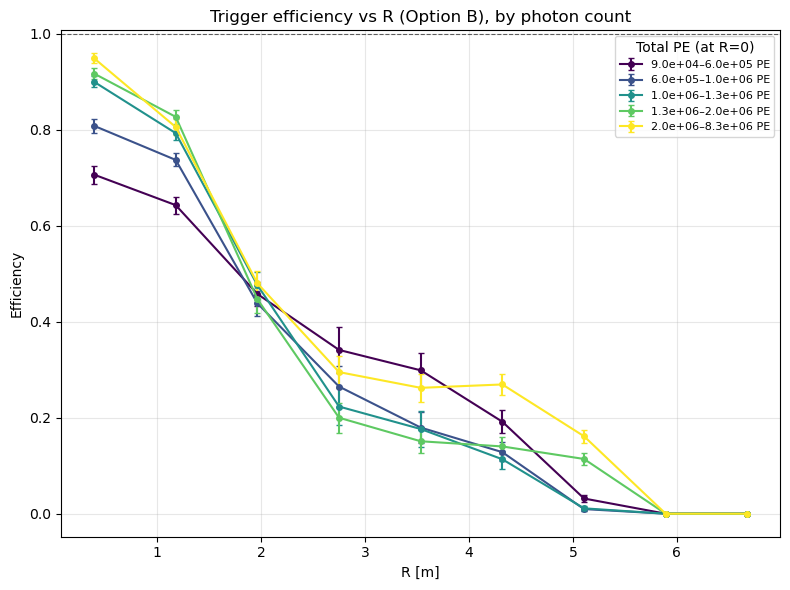

In [160]:
import numpy as np
import matplotlib.pyplot as plt

# ── Trigger outcome at each event's actual R position ────────────────────────
triggered = (Max_PE >= 20).astype(float)

# ── Exclude R=0 events that did NOT trigger ──────────────────────────────────
keep = ~((R == 0) & (triggered == 0))

# ── Reference efficiency at R=0 from the calibrated surface ──────────────────
ref_eff_photon_inc, _, _ = trigger_eff_ci(photon_count, Incidence)
ref_eff_photon_0, _, _ = trigger_eff_ci(photon_count, np.zeros(len(Incidence)))
ref_eff_photon = ref_eff_photon_inc/ref_eff_photon_0 
ref_eff_photon = np.clip(ref_eff_photon, 0, 1)
# ── Per-event relative efficiency: eff(R) = eff(PC, Inc, R) / eff(PC, Inc) ────
good = keep #& (ref_eff > 1e-3)
rel  = triggered[good] #* ref_eff_photon_inc[good]
rel = np.clip(rel, 0,1)
R_good  = R[good]
PC_good = photon_count[good]

# ── R binning ────────────────────────────────────────────────────────────────
R_bins    = np.linspace(R_good.min(), R_good.max(), 10)
R_centers = 0.5 * (R_bins[:-1] + R_bins[1:])
r_idx     = np.digitize(R_good, R_bins) - 1

# ── Photon-count binning (log-spaced) → one line per bin ─────────────────────
n_pc_bins = 5
pc_edges  = np.logspace(np.log10(PC_good.min()), np.log10(PC_good.max()), n_pc_bins + 1)
pc_edges = 10**np.quantile(np.log10(PC_good), np.linspace(0, 1, n_pc_bins  + 1))
# ── Bootstrap settings ────────────────────────────────────────────────────────
n_boot = 1000
rng    = np.random.default_rng(42)   # reproducible

def bootstrap_ci(values, n_boot=1000, cl=0.68, rng=rng):
    """Return (mean, lower_err, upper_err) using percentile bootstrap CI."""
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan
    # resample means
    idx        = rng.integers(0, n, size=(n_boot, n))
    boot_means = values[idx].mean(axis=1)
    point      = np.mean(values)
    lo = np.percentile(boot_means, 100 * (1 - cl) / 2)      # 16th pct
    hi = np.percentile(boot_means, 100 * (1 + cl) / 2)      # 84th pct
    return point, point - lo, hi - point

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0, 1, n_pc_bins))

for j in range(n_pc_bins):
    pc_mask = (PC_good >= pc_edges[j]) & (PC_good < pc_edges[j + 1])

    eff_R   = np.full(len(R_centers), np.nan)
    err_lo  = np.full(len(R_centers), np.nan)
    err_hi  = np.full(len(R_centers), np.nan)

    for i in range(len(R_centers)):
        m = pc_mask & (r_idx == i)
        if np.count_nonzero(m) > 0:
            eff_R[i], err_lo[i], err_hi[i] = bootstrap_ci(rel[m], n_boot=n_boot)

    label = f"{pc_edges[j]:.1e}–{pc_edges[j+1]:.1e} PE"
    ax.errorbar(R_centers, eff_R, yerr=[err_lo, err_hi],
                marker='o', ms=4, capsize=2,
                color=colors[j], label=label)

ax.set_xlabel("R [m]")
ax.set_ylabel(r"Efficiency")
ax.set_title("Trigger efficiency vs R (Option B), by photon count")
#ax.set_yscale("log")
ax.axhline(1.0, color='k', ls='--', lw=0.8, alpha=0.6)
ax.legend(title="Total PE (at R=0)", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

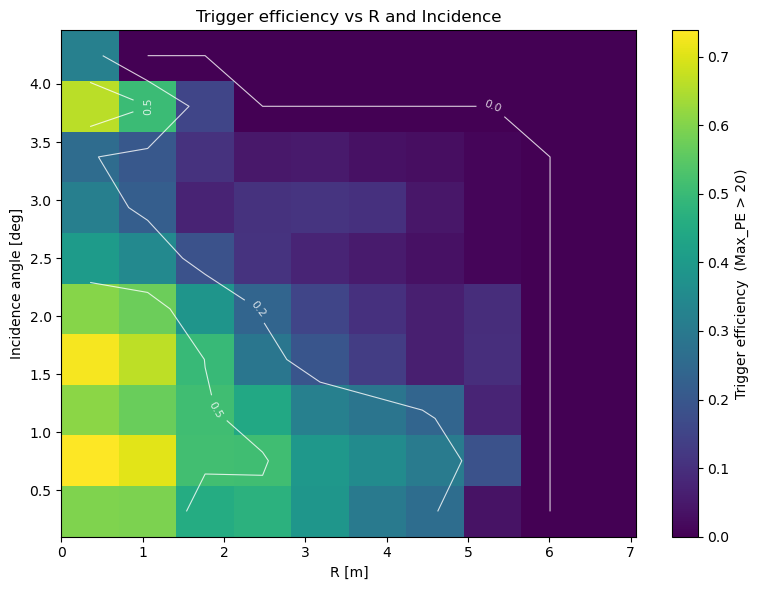

In [159]:
import numpy as np
import matplotlib.pyplot as plt

# ── Trigger outcome at each event's actual R position ────────────────────────
triggered = (Max_PE >= 20).astype(float)

ref_eff_photon_inc, _, _ = trigger_eff_ci(photon_count, Incidence)
ref_eff_photon_0, _, _ = trigger_eff_ci(photon_count, np.zeros(len(Incidence)))
ref_eff_photon = ref_eff_photon_inc/ref_eff_photon_0 
ref_eff_photon = np.clip(ref_eff_photon, 0, 1)

# ── Exclude R=0 events that did NOT trigger ──────────────────────────────────
keep = ~((R == 0) & (triggered == 0)) 

R_k    = R[keep]
Inc_k  = Incidence[keep]
trig_k =  triggered[keep] * ref_eff_photon_inc[keep]
#trig_k = np.clip(trig_k, 0,1)
# ── 2D bins in (R, Incidence) ────────────────────────────────────────────────
n_R_bins   = 10
n_Inc_bins = 10
R_edges   = np.linspace(R_k.min(),    R_k.max(),    n_R_bins   + 1)
Inc_edges = np.linspace(Inc_k.min(),  Inc_k.max(),  n_Inc_bins + 1)

# ── Trigger efficiency per bin = mean(triggered) = N_trig / N_total ───────────
sum_trig, _, _ = np.histogram2d(R_k, Inc_k, bins=[R_edges, Inc_edges], weights=trig_k)
counts,   _, _ = np.histogram2d(R_k, Inc_k, bins=[R_edges, Inc_edges])

eff = np.divide(sum_trig, counts,
                out=np.full_like(sum_trig, np.nan),
                where=counts > 0)

# ── Bin centers (for contour placement) ──────────────────────────────────────
R_centers   = 0.5 * (R_edges[:-1]   + R_edges[1:])
Inc_centers = 0.5 * (Inc_edges[:-1] + Inc_edges[1:])

# ── Plot heatmap ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(
    R_edges, Inc_edges, eff.T,        # transpose: rows=Inc, cols=R
    cmap="viridis",
    #vmin=0, vmax=1,
    shading="auto",
)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("Trigger efficiency  (Max_PE > 20)")

# ── Contour lines ────────────────────────────────────────────────────────────
levels = np.linspace(0, 1, 5)   # contours at 0.0, 0.1, ..., 1.0
cs = ax.contour(
    R_centers, Inc_centers, eff.T,   # centers align with pcolormesh cells
    levels=levels,
    colors="white",
    linewidths=0.8,
    alpha=0.8,
)
ax.clabel(cs, inline=True, fontsize=8, fmt="%.1f")

ax.set_xlabel("R [m]")
ax.set_ylabel("Incidence angle [deg]")
ax.set_title("Trigger efficiency vs R and Incidence")
plt.tight_layout()
plt.show()

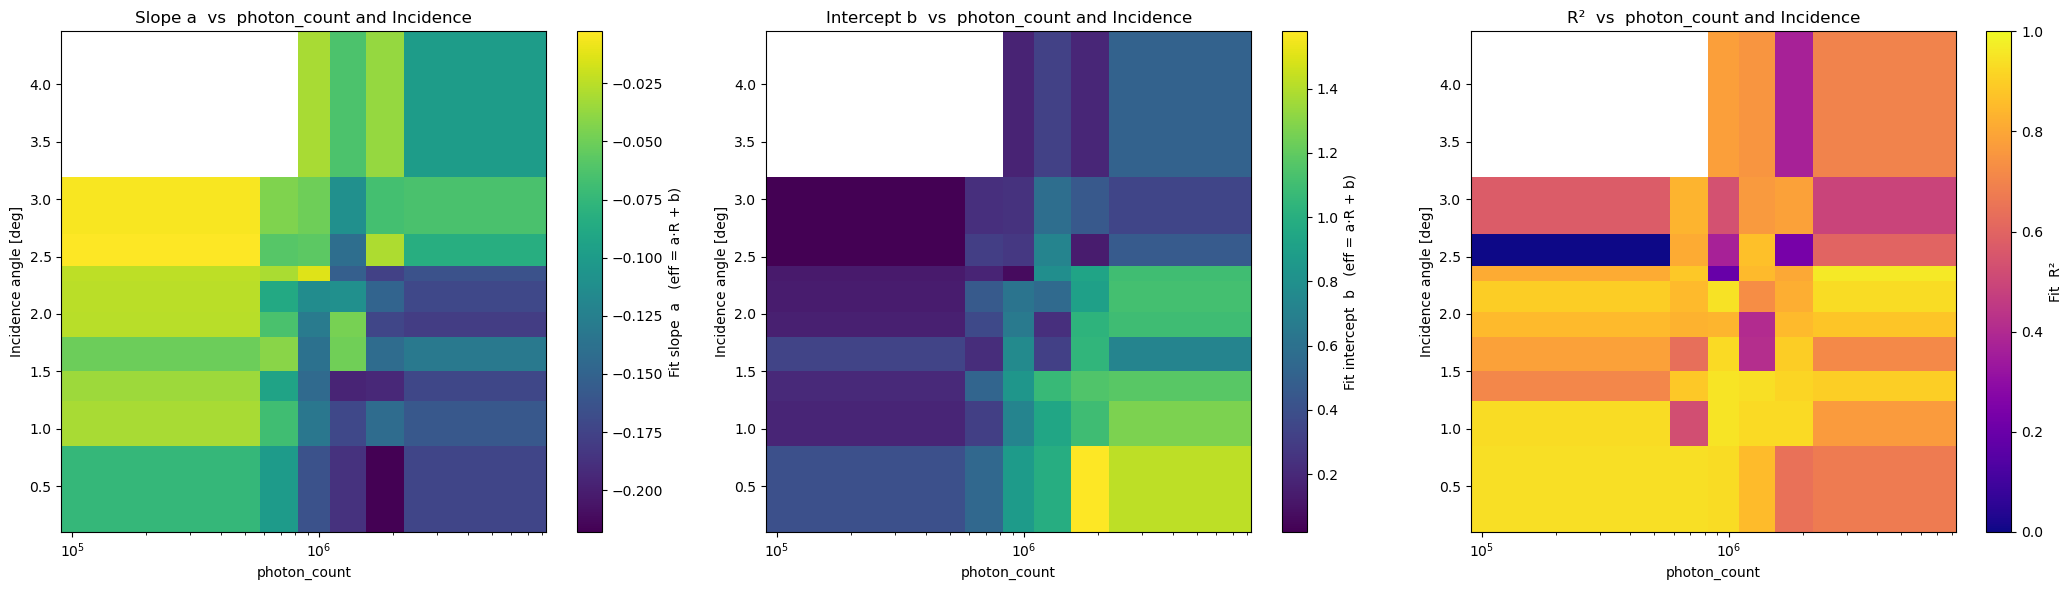

In [148]:
import numpy as np
import matplotlib.pyplot as plt

# ── Trigger outcome at each event's actual R position ────────────────────────
triggered = (Max_PE >= 20).astype(float)

# ── Exclude R=0 events that did NOT trigger ──────────────────────────────────
keep = ~((R == 0) & (triggered == 0))

R_k    = R[keep]
Inc_k  = Incidence[keep]
PC_k   = photon_count[keep]
ref_eff_photon_0, _, _ = trigger_eff_ci(PC_k, np.zeros(len(Inc_k)))
ref_eff_photon_inc, _, _ = trigger_eff_ci(PC_k, Inc_k)

trig_k = triggered[keep] * ref_eff_photon_inc

logPC_k = np.log10(PC_k)

# ── Equal-frequency (quantile) bins: same # of elements per bin ──────────────
n_PC_bins  = 6
n_Inc_bins = 10

# quantiles on log10(photon_count) -> even frequency in log scale
logPC_edges = np.quantile(logPC_k, np.linspace(0, 1, n_PC_bins  + 1))
Inc_edges   = np.quantile(Inc_k,   np.linspace(0, 1, n_Inc_bins + 1))

# ensure strictly increasing edges (guard against duplicate quantiles)
logPC_edges = np.unique(logPC_edges)
Inc_edges   = np.unique(Inc_edges)
n_PC_bins   = len(logPC_edges) - 1
n_Inc_bins  = len(Inc_edges)   - 1

# edges in raw photon_count for plotting on a log axis
PC_edges = 10.0 ** logPC_edges

# ── Bins in R (used to compute efficiency vs R inside each PC-Inc cell) ───────
n_R_bins = 10
R_edges   = np.linspace(R_k.min(), R_k.max(), n_R_bins + 1)
R_centers = 0.5 * (R_edges[:-1] + R_edges[1:])

# ── Arrays to store fit results ──────────────────────────────────────────────
a_fit  = np.full((n_PC_bins, n_Inc_bins), np.nan)   # slope
b_fit  = np.full((n_PC_bins, n_Inc_bins), np.nan)   # intercept
r2_fit = np.full((n_PC_bins, n_Inc_bins), np.nan)   # R^2

# ── Assign each event to a PC and Inc bin ────────────────────────────────────
pc_idx  = np.digitize(logPC_k, logPC_edges) - 1
inc_idx = np.digitize(Inc_k,   Inc_edges)   - 1
# clip edge cases (values exactly at max edge)
pc_idx  = np.clip(pc_idx,  0, n_PC_bins  - 1)
inc_idx = np.clip(inc_idx, 0, n_Inc_bins - 1)

# ── Loop over each (photon_count, Incidence) cell ────────────────────────────
for i in range(n_PC_bins):
    for j in range(n_Inc_bins):
        cell = (pc_idx == i) & (inc_idx == j)
        if cell.sum() < 2:
            continue

        R_cell    = R_k[cell]
        trig_cell = trig_k[cell]

        # efficiency vs R inside this cell (binned in R)
        sum_trig, _ = np.histogram(R_cell, bins=R_edges, weights=trig_cell)
        counts,   _ = np.histogram(R_cell, bins=R_edges)

        good = counts > 0
        if good.sum() < 2:          # need >=2 R points to fit a line
            continue

        eff_R = sum_trig[good] / counts[good]
        x     = R_centers[good]
        w     = counts[good]

        # weighted linear fit: weight by counts (more events = more reliable)
        a, b = np.polyfit(x, eff_R, deg=1, w=w)

        a_fit[i, j] = a
        b_fit[i, j] = b

        # ── weighted R^2 ─────────────────────────────────────────────────────
        y_pred  = a * x + b
        y_wmean = np.average(eff_R, weights=w)
        ss_res  = np.sum(w * (eff_R - y_pred)**2)
        ss_tot  = np.sum(w * (eff_R - y_wmean)**2)
        if ss_tot > 0:
            r2_fit[i, j] = 1.0 - ss_res / ss_tot

# ── Plot: slope (a), intercept (b), and R^2 heatmaps ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# --- slope a ---
pcm0 = axes[0].pcolormesh(
    PC_edges, Inc_edges, a_fit.T,   # rows=Inc, cols=PC
    cmap="viridis", shading="flat",
)
cbar0 = fig.colorbar(pcm0, ax=axes[0])
cbar0.set_label("Fit slope  a   (eff = a·R + b)")
axes[0].set_xlabel("photon_count")
axes[0].set_ylabel("Incidence angle [deg]")
axes[0].set_title("Slope a  vs  photon_count and Incidence")
axes[0].set_xscale("log")

# --- intercept b ---
pcm1 = axes[1].pcolormesh(
    PC_edges, Inc_edges, b_fit.T,
    cmap="viridis", shading="flat",
)
cbar1 = fig.colorbar(pcm1, ax=axes[1])
cbar1.set_label("Fit intercept  b   (eff = a·R + b)")
axes[1].set_xlabel("photon_count")
axes[1].set_ylabel("Incidence angle [deg]")
axes[1].set_title("Intercept b  vs  photon_count and Incidence")
axes[1].set_xscale("log")

# --- R^2 ---
pcm2 = axes[2].pcolormesh(
    PC_edges, Inc_edges, r2_fit.T,
    cmap="plasma", shading="flat",
    vmin=0, vmax=1,
)
cbar2 = fig.colorbar(pcm2, ax=axes[2])
cbar2.set_label("Fit  R²")
axes[2].set_xlabel("photon_count")
axes[2].set_ylabel("Incidence angle [deg]")
axes[2].set_title("R²  vs  photon_count and Incidence")
axes[2].set_xscale("log")

plt.tight_layout()
plt.show()

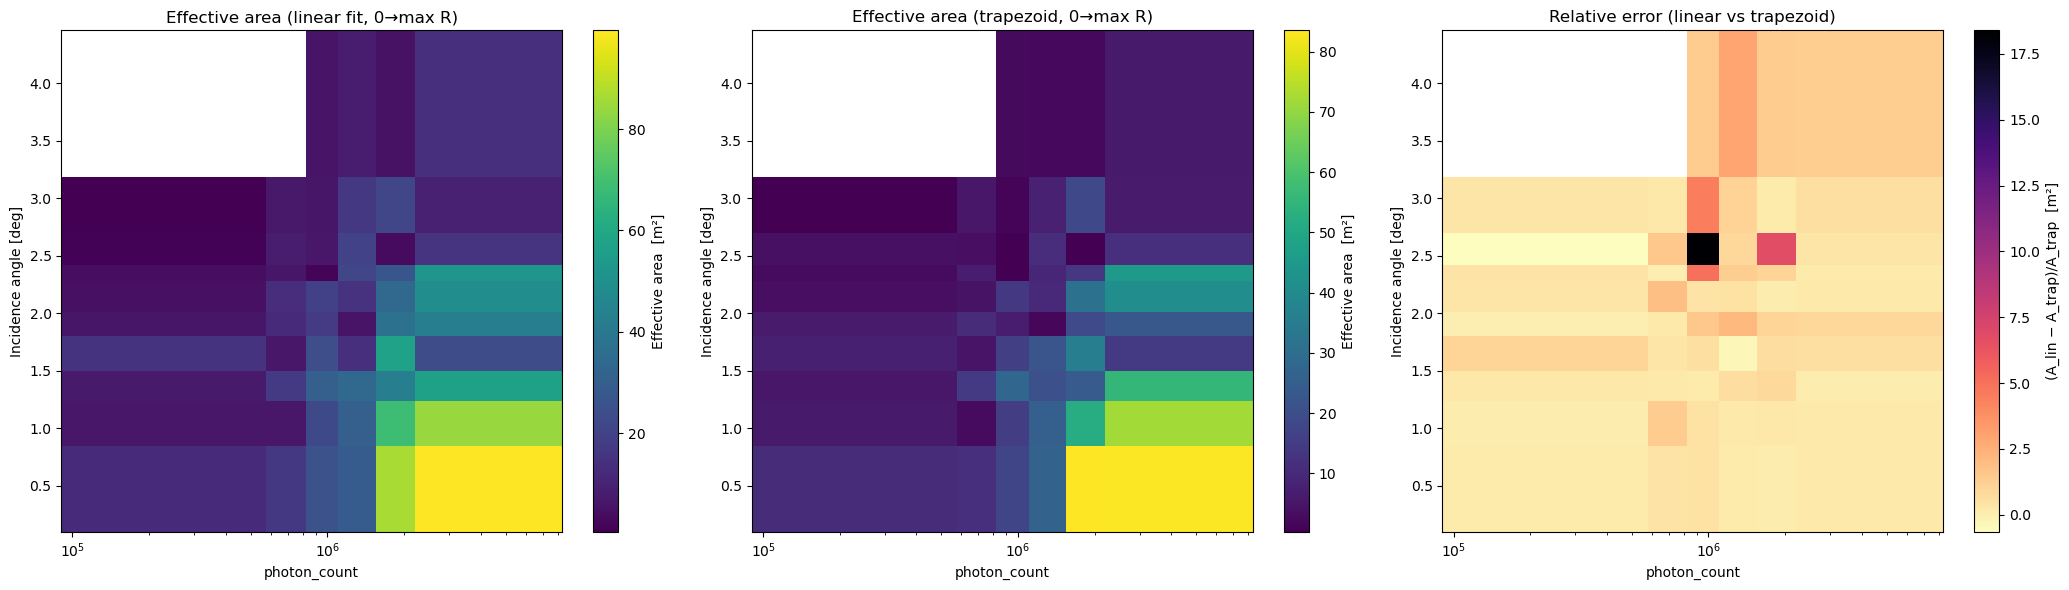

In [168]:
import numpy as np
import matplotlib.pyplot as plt

# ── Trigger outcome at each event's actual R position ────────────────────────
triggered = (Max_PE >= 20).astype(float)

# ── Exclude R=0 events that did NOT trigger ──────────────────────────────────
keep = ~((R == 0) & (triggered == 0))

R_k    = R[keep]
Inc_k  = Incidence[keep]
PC_k   = photon_count[keep]
ref_eff_photon_0, _, _ = trigger_eff_ci(PC_k, np.zeros(len(Inc_k)))
ref_eff_photon_inc, _, _ = trigger_eff_ci(PC_k, Inc_k)

trig_k = triggered[keep] * ref_eff_photon_inc
logPC_k = np.log10(PC_k)

# ── Equal-frequency (quantile) bins ──────────────────────────────────────────
n_PC_bins  = 6
n_Inc_bins = 10

logPC_edges = np.quantile(logPC_k, np.linspace(0, 1, n_PC_bins  + 1))
Inc_edges   = np.quantile(Inc_k,   np.linspace(0, 1, n_Inc_bins + 1))

logPC_edges = np.unique(logPC_edges)
Inc_edges   = np.unique(Inc_edges)
n_PC_bins   = len(logPC_edges) - 1
n_Inc_bins  = len(Inc_edges)   - 1

PC_edges = 10.0 ** logPC_edges

# ── Bins in R ────────────────────────────────────────────────────────────────
n_R_bins = 10
R_edges   = np.linspace(R_k.min(), R_k.max(), n_R_bins + 1)
R_centers = 0.5 * (R_edges[:-1] + R_edges[1:])

R_LIN_MAX = 6.0   # linear method integrates 0 -> 10

# ── Arrays to store effective area ───────────────────────────────────────────
Aeff_lin   = np.full((n_PC_bins, n_Inc_bins), np.nan)   # linear-fit method
Aeff_trap  = np.full((n_PC_bins, n_Inc_bins), np.nan)   # trapezoid method

# ── Assign each event to a PC and Inc bin ────────────────────────────────────
pc_idx  = np.digitize(logPC_k, logPC_edges) - 1
inc_idx = np.digitize(Inc_k,   Inc_edges)   - 1
pc_idx  = np.clip(pc_idx,  0, n_PC_bins  - 1)
inc_idx = np.clip(inc_idx, 0, n_Inc_bins - 1)

# ── Loop over each (photon_count, Incidence) cell ────────────────────────────
for i in range(n_PC_bins):
    for j in range(n_Inc_bins):
        cell = (pc_idx == i) & (inc_idx == j)
        if cell.sum() < 2:
            continue

        R_cell    = R_k[cell]
        trig_cell = trig_k[cell]

        sum_trig, _ = np.histogram(R_cell, bins=R_edges, weights=trig_cell)
        counts,   _ = np.histogram(R_cell, bins=R_edges)

        good = counts > 0
        if good.sum() < 2:
            continue

        eff_R = sum_trig[good] / counts[good]
        x     = R_centers[good]
        w     = counts[good]

        # ── Trapezoid method: integrate eff(R)*2*pi*R dR directly from data ──
        # 0 -> max R, using the binned efficiency points
        integrand = eff_R * 2.0 * np.pi * x
        Aeff_trap[i, j] = np.trapezoid(integrand, x)

        # ── Linear-fit method: eff(R) = a*R + b, integrate 0 -> 10 ───────────
        a, b = np.polyfit(x, eff_R, deg=1, w=w)
        # ∫_0^Rmax (a*R + b) * 2*pi*R dR
        #   = 2*pi * (a*Rmax^3/3 + b*Rmax^2/2)
        #b=1
        #a=-0.2
        Rmax = -b/a
        Aeff_lin[i, j] = 2.0 * np.pi * (a * Rmax**3 / 3.0 + b * Rmax**2 / 2.0)

# ── Absolute error between the two methods ───────────────────────────────────
abs_err = ((Aeff_lin - Aeff_trap)) 
rel_err = abs_err/Aeff_trap
# ── Plot: linear, trapezoid, absolute error ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# --- linear method ---
pcm0 = axes[0].pcolormesh(
    PC_edges, Inc_edges, Aeff_lin.T,
    cmap="viridis", shading="flat",
)
cbar0 = fig.colorbar(pcm0, ax=axes[0])
cbar0.set_label("Effective area  [m²]")
axes[0].set_xlabel("photon_count")
axes[0].set_ylabel("Incidence angle [deg]")
axes[0].set_title("Effective area (linear fit, 0→max R)")
axes[0].set_xscale("log")

# --- trapezoid method ---
pcm1 = axes[1].pcolormesh(
    PC_edges, Inc_edges, Aeff_trap.T,
    cmap="viridis", shading="flat",
)
cbar1 = fig.colorbar(pcm1, ax=axes[1])
cbar1.set_label("Effective area  [m²]")
axes[1].set_xlabel("photon_count")
axes[1].set_ylabel("Incidence angle [deg]")
axes[1].set_title("Effective area (trapezoid, 0→max R)")
axes[1].set_xscale("log")

# --- absolute error ---
pcm2 = axes[2].pcolormesh(
    PC_edges, Inc_edges, rel_err.T,
    cmap="magma_r", shading="flat",
)
cbar2 = fig.colorbar(pcm2, ax=axes[2])
cbar2.set_label("(A_lin − A_trap)/A_trap  [m²]")
axes[2].set_xlabel("photon_count")
axes[2].set_ylabel("Incidence angle [deg]")
axes[2].set_title("Relative error (linear vs trapezoid)")
axes[2].set_xscale("log")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'photon count')

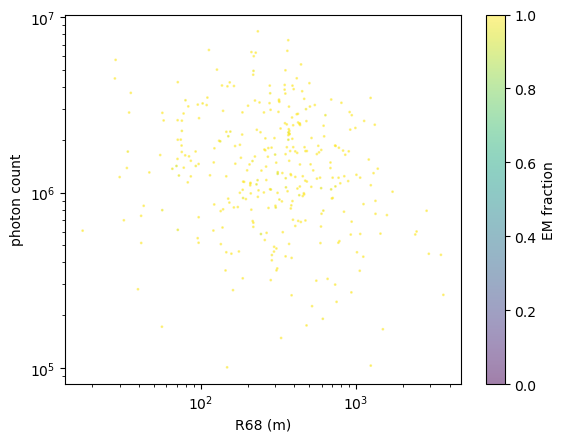

In [169]:
#plt.scatter(gamma_component*total_particles, photon_count)
mask = (Max_PE>=20)#&(Energy_GeV<1e6)
plt.scatter(r68_m[mask], photon_count[mask], s = 1, c = ((electron_component+gamma_component)[mask]), alpha = 0.5)
#plt.scatter(muon_component*total_particles, photon_count)
plt.colorbar(label="EM fraction")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("R68 (m)")
plt.ylabel("photon count")

/tmp/ipykernel_3845655/935476829.py:19: RuntimeWarning: Mean of empty slice
  had_comp.append(np.nanmean(hadronic_component[mask]*total_particles[mask]))
/tmp/ipykernel_3845655/935476829.py:20: RuntimeWarning: Mean of empty slice
  em_comp.append(np.nanmean(electron_component[mask]*total_particles[mask]))
/tmp/ipykernel_3845655/935476829.py:21: RuntimeWarning: Mean of empty slice
  muon_comp.append(np.nanmean(muon_component[mask]*total_particles[mask]))
/tmp/ipykernel_3845655/935476829.py:22: RuntimeWarning: Mean of empty slice
  R68.append(np.nanmean(r68_m[mask]))


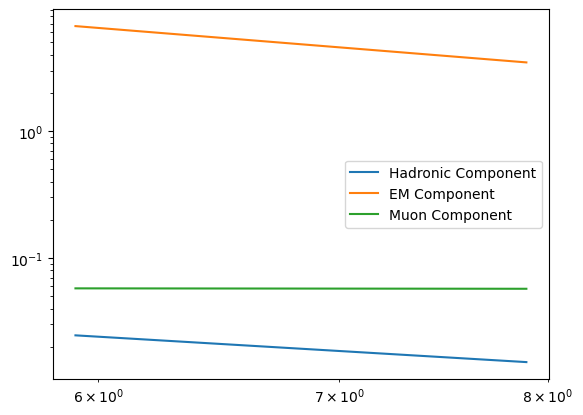

In [8]:
E_set = np.logspace(2,6,10) #np.sort(np.array(list(set(Energy_GeV))))
"""
total_particles    = np.array(df["total_particles"])
muon_component     = np.array(df["muon_component"])
electron_component = np.array(df["electron_component"])
hadronic_component = np.array(df["hadronic_component"])
gamma_component    = np.array(df["gamma_component"])
other_component    = np.array(df["other_component"])"""
had_comp = []
em_comp = []
muon_comp = []
R68 = []
Trigger = []
for i in range(len(E_set)-1):
    mask = (Energy_GeV<E_set[i+1])&(Energy_GeV>=E_set[i])
    mask2 = (Energy_GeV<E_set[i+1])&(Energy_GeV>=E_set[i])&(Max_PE>=20)
    #trig_eff = len(Energy_GeV[mask2])/len(Energy_GeV[mask])
    #Trigger.append(trig_eff)
    had_comp.append(np.nanmean(hadronic_component[mask]*total_particles[mask]))
    em_comp.append(np.nanmean(electron_component[mask]*total_particles[mask]))
    muon_comp.append(np.nanmean(muon_component[mask]*total_particles[mask]))
    R68.append(np.nanmean(r68_m[mask]))

Trigger = np.array(Trigger)
had_comp = np.array(had_comp)
em_comp = np.array(em_comp)
muon_comp = np.array(muon_comp)
R68 = np.array(R68)
plt.plot(R68, had_comp, label="Hadronic Component")
plt.plot(R68, em_comp, label="EM Component")
plt.plot(R68, muon_comp, label="Muon Component")

plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.show()

/tmp/ipykernel_364522/2476222416.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10(r99_m), bins =100, density =True, label = "R 99%", alpha = 0.5)


ValueError: supplied range of [-inf, 5.219329795174855] is not finite

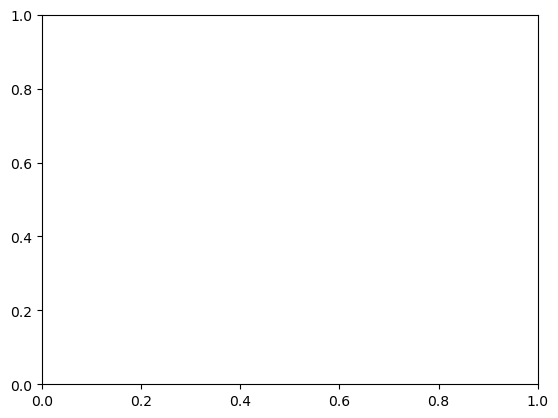

In [25]:
plt.hist(np.log10(r99_m), bins =100, density =True, label = "R 99%", alpha = 0.5)
plt.hist(np.log10(r68_m), bins =100, density =True, label = "R 68%", alpha = 0.5)
plt.yscale("log")
plt.xlabel("log10(R[m])")
plt.ylabel("Density")
plt.legend()

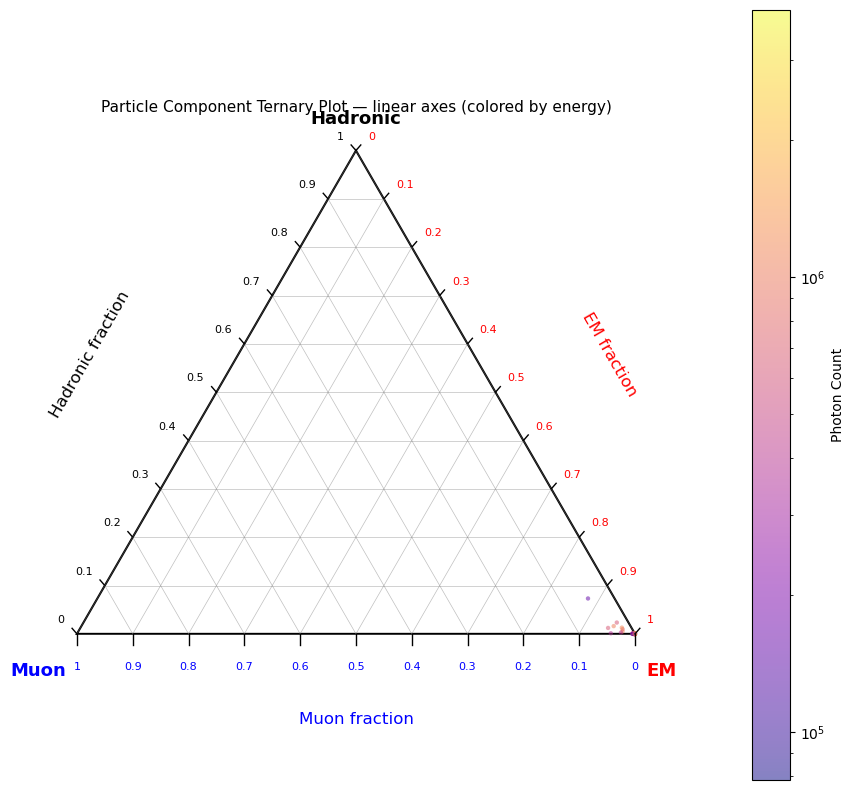

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ---- Build the three combined fractions ----
muon = df["muon_component"].values
em   = df["electron_component"].values + df["gamma_component"].values
had  = df["hadronic_component"].values + df["other_component"].values

# ---- Renormalize (guard against rounding so they sum to 1) ----
total = muon + em + had
good = total > 0
muon, em, had = muon[good], em[good], had[good]
total = total[good]
muon, em, had = muon / total, em / total, had / total

energy = photon_count[good]  # Energy_GeV[good]

# ---- Ternary -> Cartesian (linear fractions, no warp) ----
h = np.sqrt(3) / 2.0
x = em + had / 2.0
y = had * h

# ---- Plot ----
fig, ax = plt.subplots(figsize=(9, 8))

# Triangle outline
corners = np.array([[0, 0], [1, 0], [0.5, h]])
triangle = plt.Polygon(corners, closed=True, fill=False, edgecolor="black", lw=1.5)
ax.add_patch(triangle)

# ---- Evenly-spaced linear ticks ----
tick_fracs = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
tick_len = 0.02

for f in tick_fracs:
    fw = f   # linear position (0..1) along the axis

    # --- Constant Hadronic lines (horizontal) ---
    ax.plot([fw/2, 1 - fw/2], [fw*h, fw*h], color="gray", lw=0.5, alpha=0.5)
    # --- Constant Muon lines ---
    ax.plot([fw, fw + (1-fw)/2], [0, (1-fw)*h], color="gray", lw=0.5, alpha=0.5)
    # --- Constant EM lines ---
    ax.plot([(1-fw)/2, 1-fw], [(1-fw)*h, 0], color="gray", lw=0.5, alpha=0.5)

    # --- Muon axis ticks & labels (bottom edge) ---
    xm = 1 - fw
    ax.plot([xm, xm], [0, -tick_len], color="black", lw=1)
    ax.text(xm, -tick_len - 0.03, f"{f:g}", ha="center", va="top", fontsize=8, color="blue")

    # --- EM axis ticks & labels (right edge) ---
    xe = 0.5 + fw * 0.5
    ye = h - fw * h
    dx, dy = h * 0.5, 0.5
    ax.plot([xe, xe + tick_len*dx], [ye, ye + tick_len*dy], color="black", lw=1)
    ax.text(xe + (tick_len + 0.03)*dx, ye + (tick_len + 0.03)*dy,
            f"{f:g}", ha="left", va="center", fontsize=8, color="red")

    # --- Hadronic axis ticks & labels (left edge) ---
    xh = fw * 0.5
    yh = fw * h
    dxh, dyh = -h * 0.5, 0.5
    ax.plot([xh, xh + tick_len*dxh], [yh, yh + tick_len*dyh], color="black", lw=1)
    ax.text(xh + (tick_len + 0.03)*dxh, yh + (tick_len + 0.03)*dyh,
            f"{f:g}", ha="right", va="center", fontsize=8, color="black")

# ---- Scatter colored by energy (log scale) ----
sc = ax.scatter(x, y, c=energy, cmap="plasma", norm=LogNorm(),
                s=10, alpha=0.5, edgecolors="none")

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Photon Count")

# ---- Corner labels ----
ax.text(-0.02, -0.05, "Muon", ha="right", va="top",
        fontsize=13, fontweight="bold", color="blue")
ax.text(1.02, -0.05, "EM", ha="left", va="top",
        fontsize=13, fontweight="bold", color="red")
ax.text(0.5, h + 0.04, "Hadronic", ha="center", va="bottom",
        fontsize=13, fontweight="bold", color="black")

# ---- Axis (side) labels ----
ax.text(0.5, -0.14, "Muon fraction", ha="center", va="top",
        fontsize=12, color="blue")
ax.text(0.80 + 0.10, 0.45 + 0.05, "EM fraction", ha="left", va="center",
        rotation=-60, fontsize=12, color="red")
ax.text(0.20 - 0.10, 0.45 + 0.05, "Hadronic fraction", ha="right", va="center",
        rotation=60, fontsize=12, color="black")

# ---- Final formatting ----
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Particle Component Ternary Plot — linear axes (colored by energy)",
             fontsize=11)

plt.tight_layout()
plt.savefig("component_ternary_linear.png", dpi=200)
plt.show()

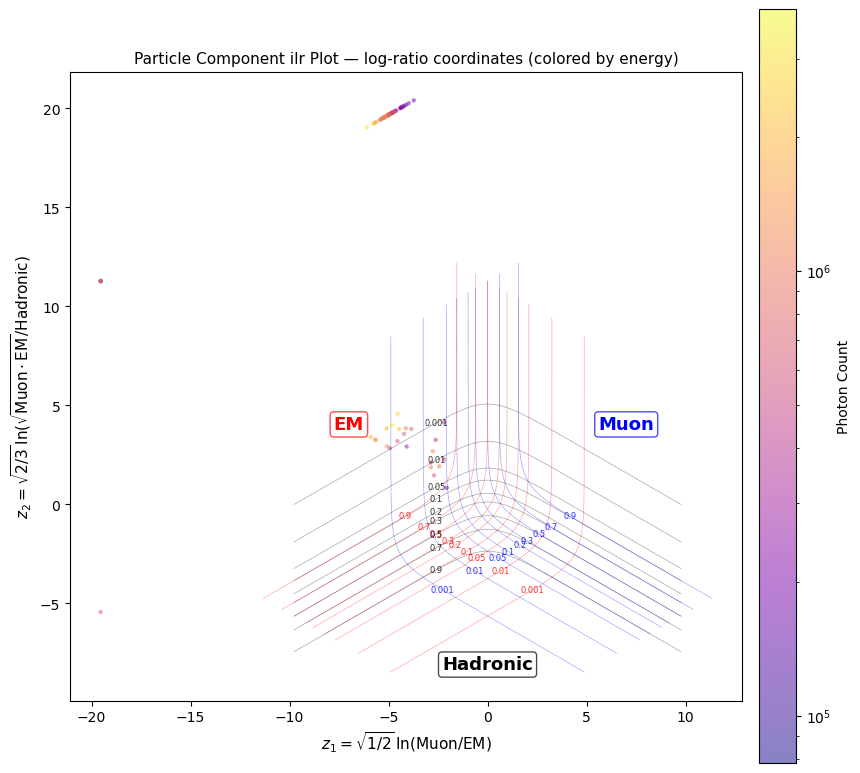

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ---- Isometric log-ratio (ilr) of a 3-part composition -> 2D ----
def ilr_coords(a, b, c):
    """Map composition (a,b,c) with a+b+c=1 to 2D ilr coordinates.
    a -> muon, b -> em, c -> hadronic (order matters for orientation)."""
    eps = 1e-12
    a = np.asarray(a, dtype=float) + eps
    b = np.asarray(b, dtype=float) + eps
    c = np.asarray(c, dtype=float) + eps
    s = a + b + c
    a, b, c = a/s, b/s, c/s
    z1 = np.sqrt(1.0/2.0) * np.log(a / b)
    z2 = np.sqrt(2.0/3.0) * np.log(np.sqrt(a*b) / c)
    return z1, z2

# ---- Build the three combined fractions ----
muon = df["muon_component"].values
em   = df["electron_component"].values + df["gamma_component"].values
had  = df["hadronic_component"].values + df["other_component"].values

# ---- Renormalize (guard against rounding so they sum to 1) ----
total = muon + em + had
good = total > 0
muon, em, had = muon[good], em[good], had[good]
total = total[good]
muon, em, had = muon / total, em / total, had / total

energy = photon_count[good]  # Energy_GeV[good]

# ---- Data in ilr coordinates ----
x, y = ilr_coords(muon, em, had)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(9, 8))

# ---------------------------------------------------------------
# Reference gridlines: curves of constant fraction for each component.
# A "constant a = k" line is the set of compositions where one component
# is fixed; we parametrize the remaining two and map through ilr.
# ---------------------------------------------------------------
grid_fracs = np.array([0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9])
t = np.linspace(1e-6, 1 - 1e-6, 400)  # parametrizes split of the remaining (1-k)

def const_component_line(k, which):
    """Return ilr (x,y) for the locus where 'which' component == k.
    The other two components share the remaining (1-k)."""
    rem = 1.0 - k
    p = t * rem          # first of the remaining two
    q = rem - p          # second of the remaining two
    if which == "muon":       # a = k ; b,c = p,q
        a, b, c = np.full_like(t, k), p, q
    elif which == "em":       # b = k ; a,c = p,q
        a, b, c = p, np.full_like(t, k), q
    else:                     # had = k ; a,b = p,q
        a, b, c = p, q, np.full_like(t, k)
    return ilr_coords(a, b, c)

# Draw constant-fraction curves for each component
line_styles = {
    "muon": dict(color="blue",  lw=0.5, alpha=0.35),
    "em":   dict(color="red",   lw=0.5, alpha=0.35),
    "had":  dict(color="black", lw=0.5, alpha=0.35),
}
for k in grid_fracs:
    for which, style in [("muon", line_styles["muon"]),
                         ("em",   line_styles["em"]),
                         ("had",  line_styles["had"])]:
        gx, gy = const_component_line(k, which)
        ax.plot(gx, gy, **style)
        # label near one end of each curve
        ax.text(gx[10], gy[10], f"{k:g}", fontsize=6,
                color=style["color"], alpha=0.8,
                ha="center", va="center")

# ---- Scatter colored by energy / photon count (log scale) ----
sc = ax.scatter(x, y, c=energy, cmap="plasma", norm=LogNorm(),
                s=10, alpha=0.5, edgecolors="none")

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Photon Count")

# ---- Corner (pure-component) reference points ----
# Pure compositions map to infinity in ilr, so use near-pure proxies.
pure = 1.0 - 1e-4
half = 0.5e-4
corner_defs = {
    "Muon":     (pure, half, half, "blue"),
    "EM":       (half, pure, half, "red"),
    "Hadronic": (half, half, pure, "black"),
}
for name, (a, b, c, col) in corner_defs.items():
    cx, cy = ilr_coords(a, b, c)
    cx, cy = float(cx), float(cy)
    ax.text(cx, cy, name, ha="center", va="center",
            fontsize=13, fontweight="bold", color=col,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=col, alpha=0.7))

# ---- Axis labels (ilr balances) ----
ax.set_xlabel(r"$z_1 = \sqrt{1/2}\,\ln(\mathrm{Muon}/\mathrm{EM})$", fontsize=11)
ax.set_ylabel(r"$z_2 = \sqrt{2/3}\,\ln(\sqrt{\mathrm{Muon}\cdot\mathrm{EM}}/\mathrm{Hadronic})$",
              fontsize=11)

ax.set_aspect("equal")
ax.grid(False)
ax.set_title("Particle Component ilr Plot — log-ratio coordinates (colored by energy)",
             fontsize=11)
#plt.xlim(-7.5,5)
plt.tight_layout()
plt.savefig("component_ilr.png", dpi=200)
plt.show()

Adaptive incidence bin edges (deg): [0.   0.29 0.57 0.86 1.15 1.43 1.72 2.01 2.29 2.58 2.87 3.15 3.44 3.73
 4.02 4.3  4.59 4.88 5.16 5.45 5.74]
Photon-count binning mode: 'log'


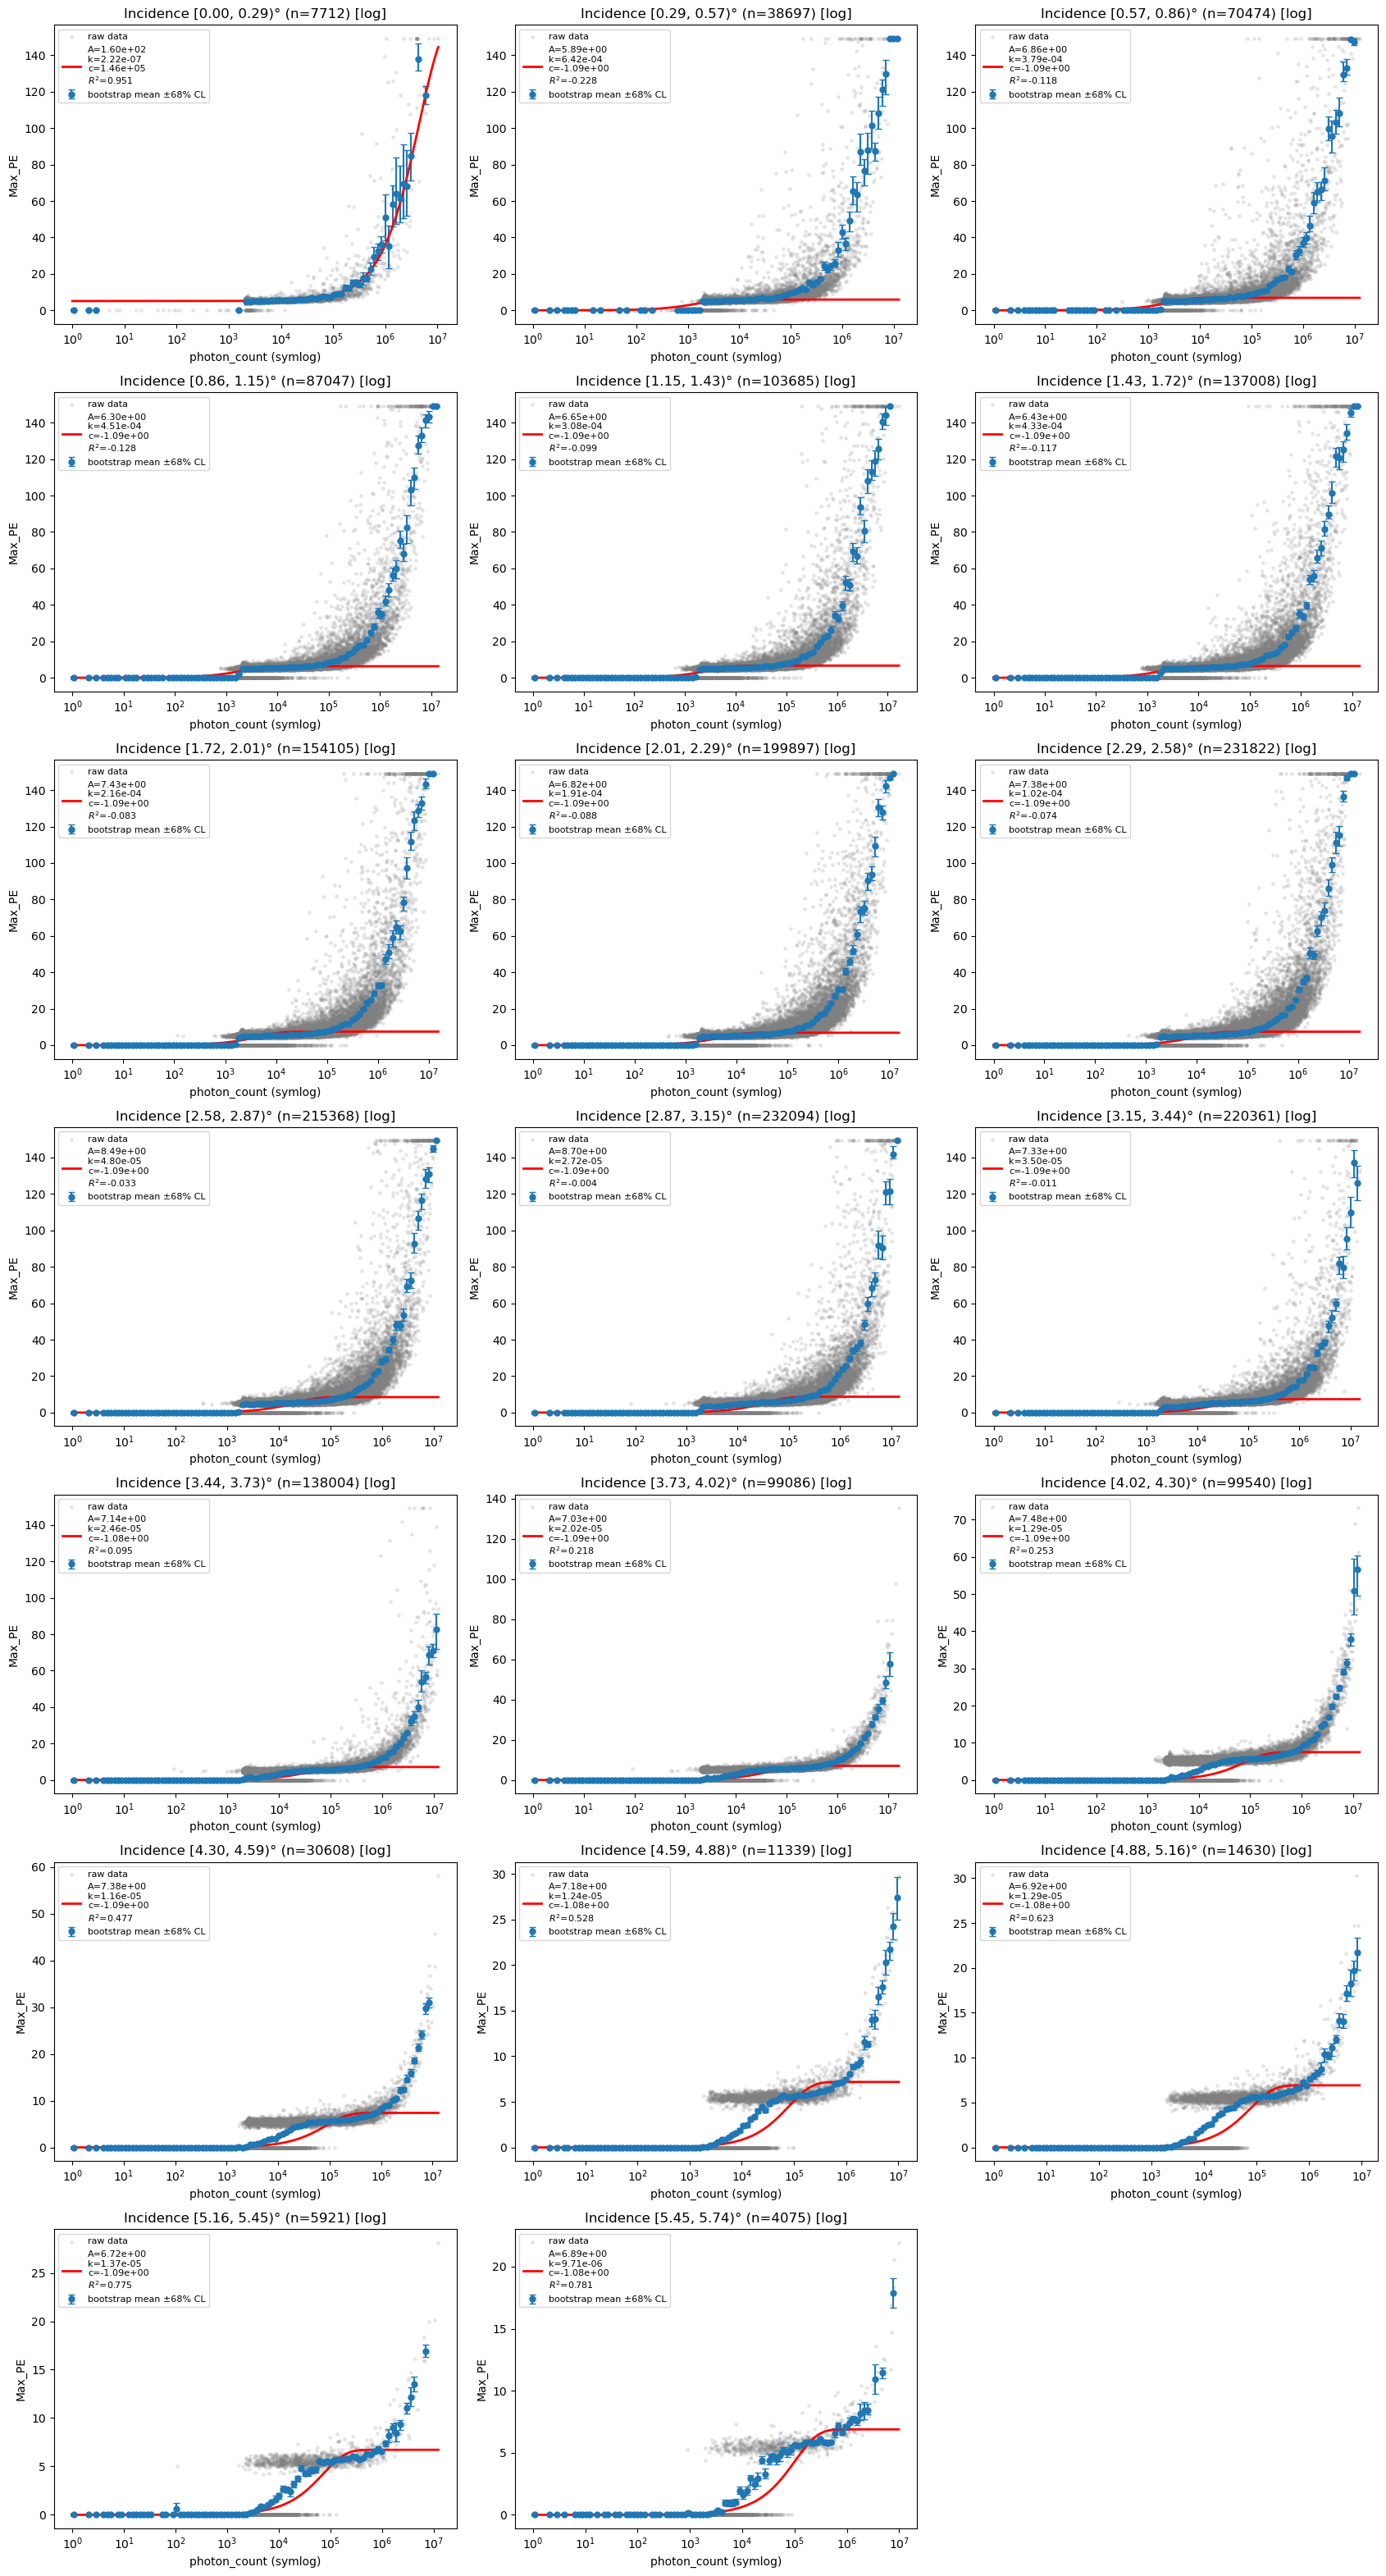


        Bin (deg)      N            A        A_err            k        k_err            c        c_err      R^2
--------------------------------------------------------------------------------------------------------------
     [0.00, 0.29)   7712    1.600e+02    1.241e+01    2.220e-07    2.183e-08    1.460e+05    4.850e+03    0.951
     [0.29, 0.57)  38697    5.894e+00    1.456e-02    6.423e-04    1.194e-05   -1.085e+00    3.165e+01   -0.228
     [0.57, 0.86)  70474    6.861e+00    1.734e-02    3.787e-04    2.806e-06   -1.085e+00    7.522e+00   -0.118
     [0.86, 1.15)  87047    6.301e+00    9.723e-03    4.507e-04    2.506e-06   -1.086e+00    6.299e+00   -0.128
     [1.15, 1.43) 103685    6.647e+00    1.142e-02    3.081e-04    1.421e-06   -1.087e+00    3.992e+00   -0.099
     [1.43, 1.72) 137008    6.432e+00    9.077e-03    4.329e-04    1.986e-06   -1.086e+00    4.940e+00   -0.117
     [1.72, 2.01) 154105    7.434e+00    1.178e-02    2.160e-04    7.188e-07   -1.086e+00    2.248e+00  

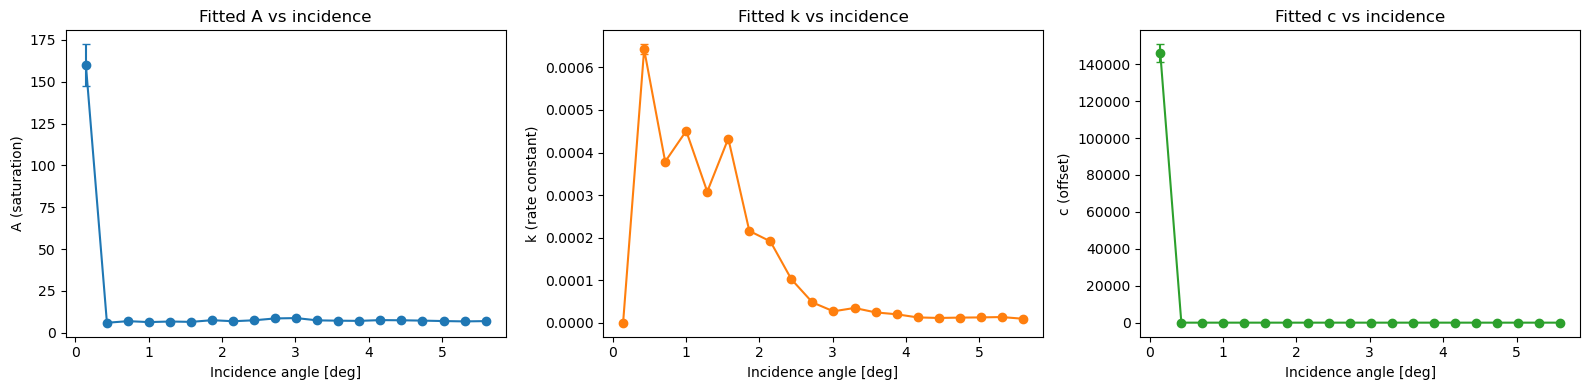

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Saturation model (now with offset c) ---
def saturation_model(photon_count, A, k, c):
    return A * (1 - np.exp(-k * (photon_count + c)))

# --- Bootstrap helper: mean + 68% CL of Max_PE in a photon-count bin ---
def bootstrap_mean_ci(values, n_boot=2000, ci=68.0, rng=None):
    """Return (mean, lo, hi) where lo/hi bound the central `ci`% of bootstrap means."""
    if rng is None:
        rng = np.random.default_rng()
    values = np.asarray(values)
    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan
    if n == 1:
        return values[0], values[0], values[0]
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_means[i] = np.mean(sample)
    mean = np.mean(values)
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return mean, lo, hi

# ===============================================================
# Photon-count binning mode:
#   "log"     -> equal-width bins in log10(photon_count)   [original]
#   "quantile"-> equal-count (adaptive quantile) bins       [new option]
# ===============================================================
BIN_MODE = "log"   # <-- switch here: "log" or "quantile"

def make_pc_edges(x_all, n_pc_bins, mode):
    """Return photon-count bin edges according to `mode`."""
    if mode == "log":
        log_lo, log_hi = np.log10(x_all.min()), np.log10(x_all.max())
        if log_hi <= log_lo:
            return None
        return np.logspace(log_lo, log_hi, n_pc_bins + 1)
    elif mode == "quantile":
        edges = np.quantile(x_all, np.linspace(0, 1, n_pc_bins + 1))
        edges = np.unique(edges)          # collapse duplicate edges
        if len(edges) < 2:
            return None
        return edges
    else:
        raise ValueError(f"Unknown BIN_MODE: {mode!r}")

rng = np.random.default_rng(42)

# ---------------------------------------------------------------
# 1) Adaptive (equal-count) incidence bins
# ---------------------------------------------------------------
n_inc_bins = 20
valid = np.isfinite(Incidence) & np.isfinite(photon_count) & np.isfinite(Max_PE) \
        & (photon_count > 0) & (Max_PE >= 0)

incidence_bin_edges = np.quantile(Incidence[valid], np.linspace(0, 1, n_inc_bins + 1))
incidence_bin_edges = np.unique(incidence_bin_edges)
incidence_bin_edges = np.linspace(np.min(Incidence[valid]), np.max(Incidence[valid]), n_inc_bins + 1)
n_inc_bins = len(incidence_bin_edges) - 1

inc_idx = np.clip(np.digitize(Incidence, incidence_bin_edges), 1, n_inc_bins)

print(f"Adaptive incidence bin edges (deg): "
      f"{np.array2string(incidence_bin_edges, precision=2)}")
print(f"Photon-count binning mode: {BIN_MODE!r}")

n_pc_bins = 100
n_boot = 100
min_per_bin = 3

# --- Plot grid ---
ncols = 3
nrows = int(np.ceil(n_inc_bins / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(17, 4.5 * nrows))
axes = np.atleast_1d(axes).ravel()

fit_results = []

for b in range(1, n_inc_bins + 1):
    mask = (inc_idx == b) & valid
    n_points = int(np.sum(mask))

    ax = axes[b - 1]
    bin_lo = incidence_bin_edges[b - 1]
    bin_hi = incidence_bin_edges[b]

    if n_points < min_per_bin:
        ax.set_title(f"[{bin_lo:.2f}, {bin_hi:.2f})° — too few points ({n_points})")
        ax.axis("off")
        continue

    x_all =  photon_count[mask] #max_photon_10ns[mask]  #
    y_all = Max_PE[mask]

    # -----------------------------------------------------------
    # 2) Photon-count bins (mode-dependent)
    # -----------------------------------------------------------
    pc_edges = make_pc_edges(x_all, n_pc_bins, BIN_MODE)
    if pc_edges is None:
        ax.set_title(f"[{bin_lo:.2f}, {bin_hi:.2f})° — degenerate pc range")
        ax.axis("off")
        continue

    n_pc_eff = len(pc_edges) - 1          # effective # bins (quantile may collapse)
    pc_digit = np.digitize(x_all, pc_edges)

    pc_centers, pe_mean, pe_lo, pe_hi = [], [], [], []

    for j in range(1, n_pc_eff + 1):
        sel = (pc_digit == j)
        if np.sum(sel) < min_per_bin:
            continue
        # geometric center for log bins, arithmetic-in-log still fine for quantile
        center = np.sqrt(pc_edges[j - 1] * pc_edges[j])
        m, lo, hi = bootstrap_mean_ci(y_all[sel], n_boot=n_boot, ci=68.0, rng=rng)
        pc_centers.append(center)
        pe_mean.append(m)
        pe_lo.append(lo)
        pe_hi.append(hi)

    pc_centers = np.array(pc_centers)
    pe_mean = np.array(pe_mean)
    pe_lo = np.array(pe_lo)
    pe_hi = np.array(pe_hi)

    yerr = np.vstack([pe_mean - pe_lo, pe_hi - pe_mean])

    # -----------------------------------------------------------
    # 3) Fit 3-parameter saturation model
    # -----------------------------------------------------------
    fit_ok = len(pc_centers) >= 3   # need >= n_params points
    if fit_ok:
        sigma = 0.5 * (yerr[0] + yerr[1])
        sigma = np.where(sigma > 0, sigma,
                         np.nanmax(sigma[sigma > 0]) if np.any(sigma > 0) else 1.0)

        A_lower, A_upper = 0, 160#np.max(pe_mean), 200.0
        if A_lower >= A_upper:
            A_lower = 0.0
        k_lower, k_upper = 0.0, 1
        c_lower, c_upper = -pc_centers.min(), pc_centers.max()*10

        A0 = float(np.clip(np.max(pe_mean), A_lower + 1e-6, A_upper - 1e-6))
        k0 = float(np.clip(1.0 / (np.median(pc_centers) + 1e-12),
                           k_lower + 1e-12, k_upper))
        c0 = float(np.clip(0.0, c_lower + 1e-6, c_upper - 1e-6))

        try:
            popt, pcov = curve_fit(
                saturation_model, pc_centers, pe_mean,
                p0=[A0, k0, c0], sigma=sigma, absolute_sigma=True,
                bounds=([A_lower, k_lower, c_lower],
                        [A_upper, k_upper, c_upper]),
                maxfev=20000
            )
            perr = np.sqrt(np.diag(pcov))
            A_fit, k_fit, c_fit = popt
            A_err, k_err, c_err = perr

            resid = pe_mean - saturation_model(pc_centers, *popt)
            ss_res = np.sum(resid**2)
            ss_tot = np.sum((pe_mean - np.mean(pe_mean))**2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

            fit_results.append({
                "bin_lo": bin_lo, "bin_hi": bin_hi,
                "bin_center": 0.5 * (bin_lo + bin_hi), "n": n_points,
                "A": A_fit, "A_err": A_err,
                "k": k_fit, "k_err": k_err,
                "c": c_fit, "c_err": c_err, "r2": r2
            })
        except RuntimeError:
            fit_ok = False

    # -----------------------------------------------------------
    # 4) Plot (symlog x-axis)
    # -----------------------------------------------------------
    ax.scatter(x_all, y_all, s=6, alpha=0.15, color="grey", label="raw data")
    ax.errorbar(pc_centers, pe_mean, yerr=yerr, fmt='o', color='C0',
                capsize=3, ms=5, label="bootstrap mean ±68% CL")

    if fit_ok:
        x_fit = np.logspace(np.log10(x_all.min()), np.log10(x_all.max()), 400)
        ax.plot(x_fit, saturation_model(x_fit, *popt), 'r-', lw=2,
                label=f"A={A_fit:.2e}\nk={k_fit:.2e}\nc={c_fit:.2e}\n$R^2$={r2:.3f}")

    linthresh = max(pc_edges[0], 1.0)
    ax.set_xscale("symlog", linthresh=linthresh)
    ax.set_title(f"Incidence [{bin_lo:.2f}, {bin_hi:.2f})° (n={n_points}) [{BIN_MODE}]")
    ax.set_xlabel("photon_count (symlog)")
    ax.set_ylabel("Max_PE")
    ax.legend(fontsize=8)

for j in range(n_inc_bins, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# --- Summary table ---
print(f"\n{'Bin (deg)':>17} {'N':>6} {'A':>12} {'A_err':>12} "
      f"{'k':>12} {'k_err':>12} {'c':>12} {'c_err':>12} {'R^2':>8}")
print("-" * 110)
for r in fit_results:
    print(f"[{r['bin_lo']:.2f}, {r['bin_hi']:.2f})".rjust(17)
          + f" {r['n']:>6}"
          + f" {r['A']:>12.3e} {r['A_err']:>12.3e}"
          + f" {r['k']:>12.3e} {r['k_err']:>12.3e}"
          + f" {r['c']:>12.3e} {r['c_err']:>12.3e}"
          + f" {r['r2']:>8.3f}")

# --- Parameter trends vs incidence ---
if fit_results:
    centers = [r["bin_center"] for r in fit_results]
    A_vals, A_errs = [r["A"] for r in fit_results], [r["A_err"] for r in fit_results]
    k_vals, k_errs = [r["k"] for r in fit_results], [r["k_err"] for r in fit_results]
    c_vals, c_errs = [r["c"] for r in fit_results], [r["c_err"] for r in fit_results]

    fig2, (axA, axK, axC) = plt.subplots(1, 3, figsize=(16, 4))
    axA.errorbar(centers, A_vals, yerr=A_errs, fmt='o-', capsize=3)
    axA.set_xlabel("Incidence angle [deg]"); axA.set_ylabel("A (saturation)")
    axA.set_title("Fitted A vs incidence")
    axK.errorbar(centers, k_vals, yerr=k_errs, fmt='o-', capsize=3, color='C1')
    axK.set_xlabel("Incidence angle [deg]"); axK.set_ylabel("k (rate constant)")
    axK.set_title("Fitted k vs incidence")
    axC.errorbar(centers, c_vals, yerr=c_errs, fmt='o-', capsize=3, color='C2')
    axC.set_xlabel("Incidence angle [deg]"); axC.set_ylabel("c (offset)")
    axC.set_title("Fitted c vs incidence")
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_2451232/1121239922.py:20: RuntimeWarning: overflow encountered in exp
  logistic   = M / (1.0 + np.exp(-r * (x - x0)))
/tmp/ipykernel_2451232/1121239922.py:176: RuntimeWarning: overflow encountered in exp
  y_logistic = popt[0] / (1 + np.exp(-popt[1] * (x_fit - popt[2])))


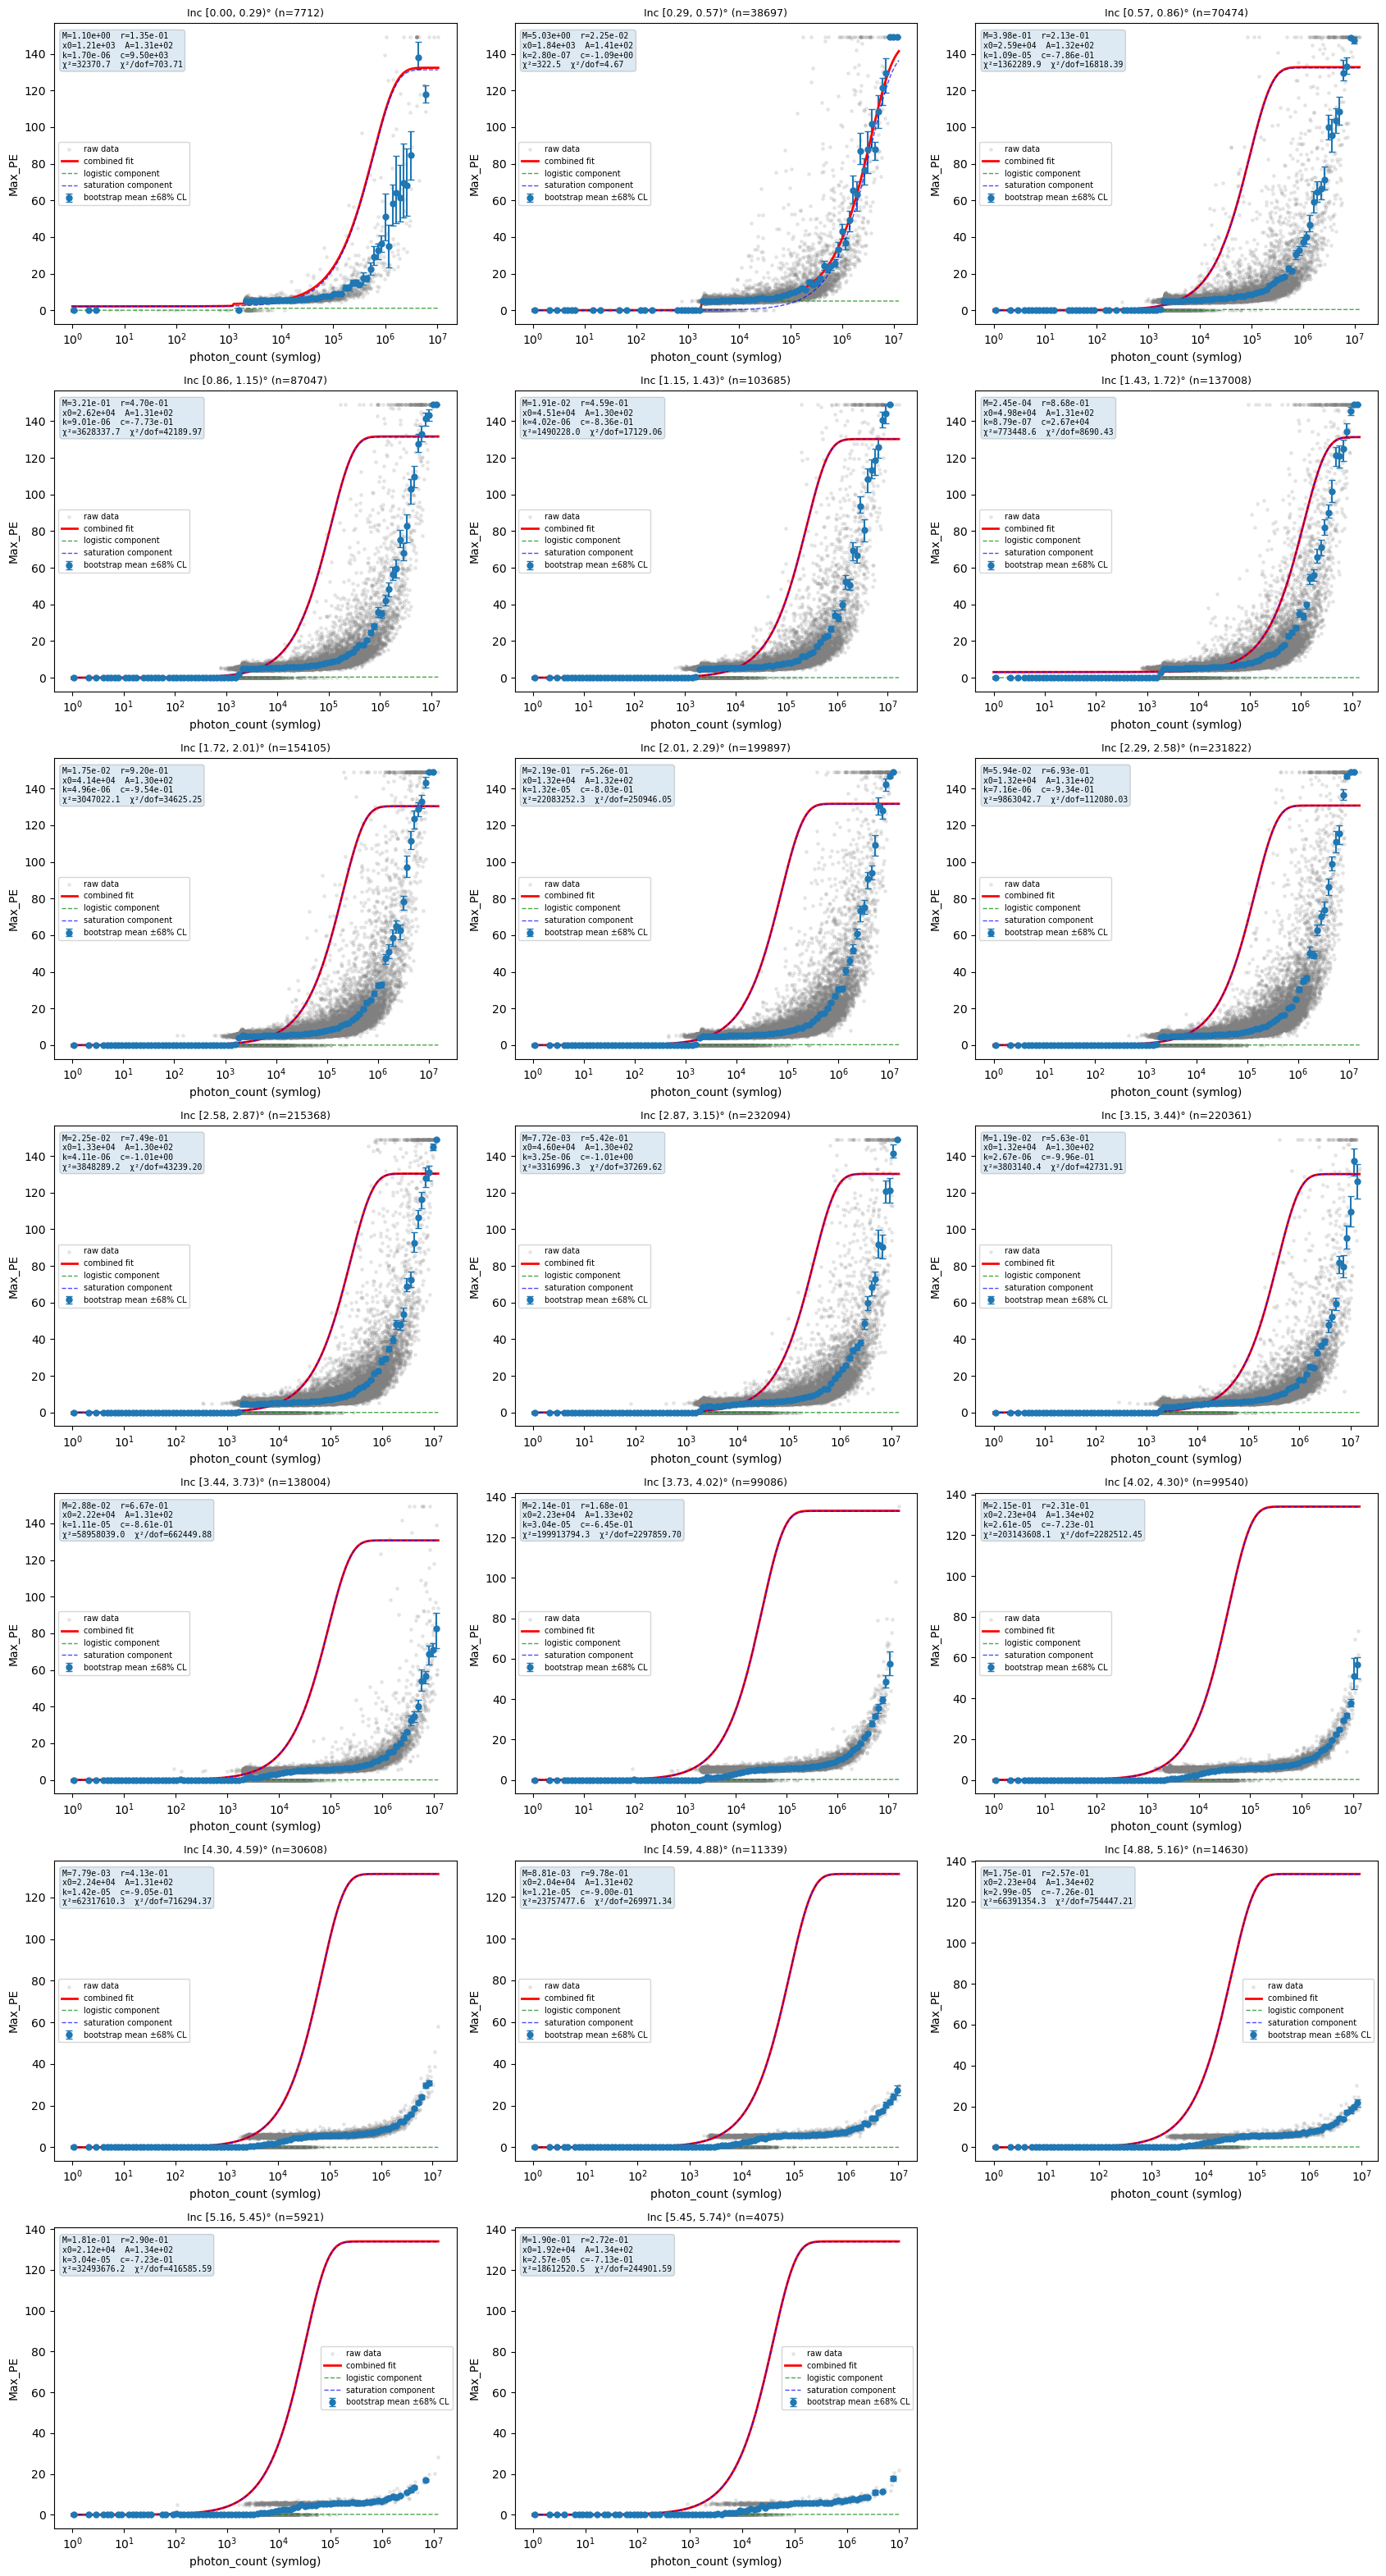


              Bin     N         M         r        x0         A         k         c     chi2  chi2/dof
-------------------------------------------------------------------------------------------------------
      [0.00,0.29)  7712  1.10e+00  1.35e-01  1.21e+03  1.31e+02  1.70e-06  9.50e+03  32370.7    703.71
      [0.29,0.57) 38697  5.03e+00  2.25e-02  1.84e+03  1.41e+02  2.80e-07 -1.09e+00    322.5      4.67
      [0.57,0.86) 70474  3.98e-01  2.13e-01  2.59e+04  1.32e+02  1.09e-05 -7.86e-01 1362289.9  16818.39
      [0.86,1.15) 87047  3.21e-01  4.70e-01  2.62e+04  1.31e+02  9.01e-06 -7.73e-01 3628337.7  42189.97
      [1.15,1.43) 103685  1.91e-02  4.59e-01  4.51e+04  1.30e+02  4.02e-06 -8.36e-01 1490228.0  17129.06
      [1.43,1.72) 137008  2.45e-04  8.68e-01  4.98e+04  1.31e+02  8.79e-07  2.67e+04 773448.6   8690.43
      [1.72,2.01) 154105  1.75e-02  9.20e-01  4.14e+04  1.30e+02  4.96e-06 -9.54e-01 3047022.1  34625.25
      [2.01,2.29) 199897  2.19e-01  5.26e-01  1.32e+04  1.32e+02

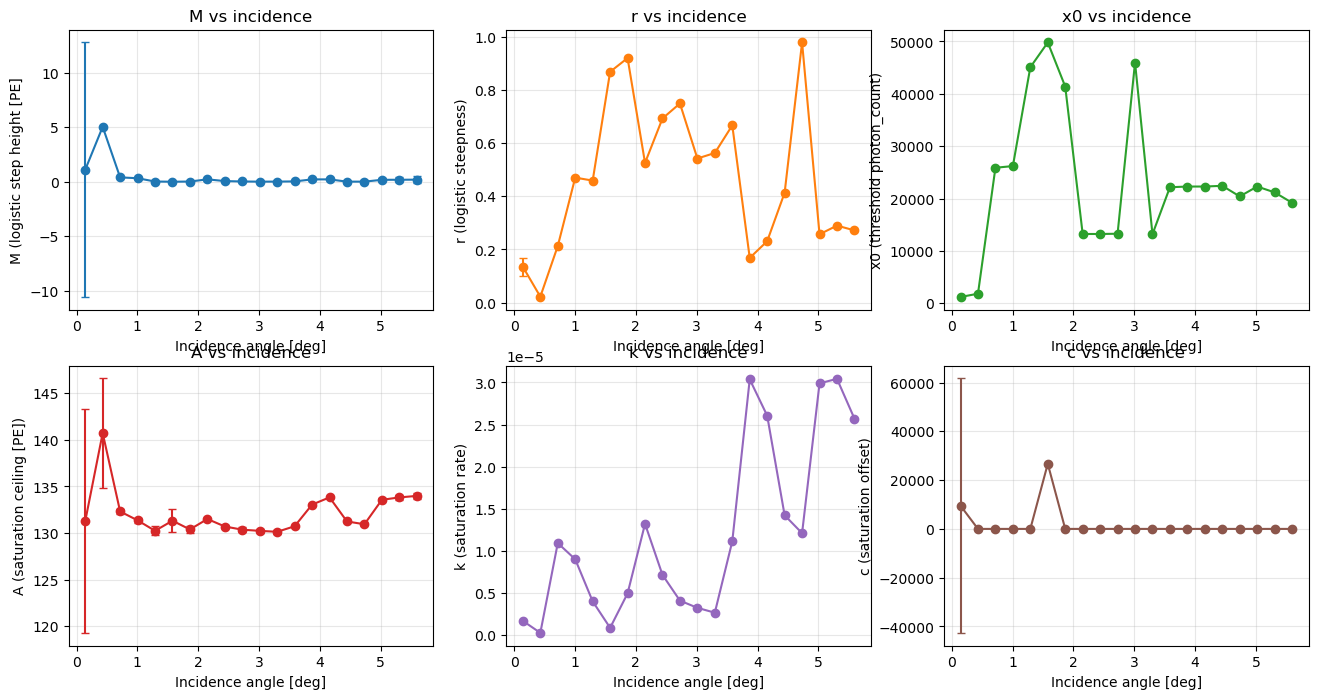

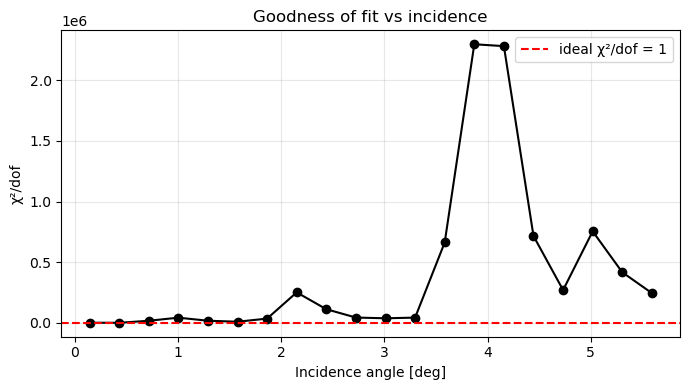

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ---------------------------------------------------------------
# Combined model:
#   logistic:   L(x) = M / (1 + exp(-r*(x - x0)))   <- turn-on at threshold
#   saturation: S(x) = A * (1 - exp(-k*(x + c)))     <- slow rise after
#   total:      f(x) = L(x) + S(x)
#
# Physical interpretation of each parameter:
#   M   : amplitude of the logistic step (≈5 PE jump at turn-on)
#   r   : steepness of the step (large r → sharp switch)
#   x0  : threshold photon_count where the step occurs (≈1e3)
#   A   : saturation ceiling of the exponential component
#   k   : rate at which saturation is approached
#   c   : horizontal offset of the saturation curve
# ---------------------------------------------------------------
def combined_model(x, M, r, x0, A, k, c):
    logistic   = M / (1.0 + np.exp(-r * (x - x0)))
    saturation = A * (1.0 - np.exp(-k * (x + c)))
    return logistic + saturation

def chi2_reduced(y_obs, y_pred, sigma, n_params):
    """Reduced chi-square: chi2 / degrees_of_freedom."""
    chi2 = np.sum(((y_obs - y_pred) / sigma) ** 2)
    dof  = max(len(y_obs) - n_params, 1)
    return chi2, chi2 / dof

# --- Bootstrap helper ---
def bootstrap_mean_ci(values, n_boot=2000, ci=68.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    values = np.asarray(values)
    n = len(values)
    if n == 0:   return np.nan, np.nan, np.nan
    if n == 1:   return values[0], values[0], values[0]
    boot_means = np.array([np.mean(rng.choice(values, size=n, replace=True))
                           for _ in range(n_boot)])
    return (np.mean(values),
            np.percentile(boot_means, (100 - ci) / 2),
            np.percentile(boot_means, 100 - (100 - ci) / 2))

# --- Photon-count bin edges ---
BIN_MODE = "log"

def make_pc_edges(x_all, n_pc_bins, mode):
    if mode == "log":
        log_lo, log_hi = np.log10(x_all.min()), np.log10(x_all.max())
        if log_hi <= log_lo: return None
        return np.logspace(log_lo, log_hi, n_pc_bins + 1)
    elif mode == "quantile":
        edges = np.unique(np.quantile(x_all, np.linspace(0, 1, n_pc_bins + 1)))
        return edges if len(edges) >= 2 else None
    else:
        raise ValueError(f"Unknown BIN_MODE: {mode!r}")

rng = np.random.default_rng(42)
N_PARAMS = 6   # M, r, x0, A, k, c

# --- Incidence bins ---
n_inc_bins = 20
valid = (np.isfinite(Incidence) & np.isfinite(photon_count) & np.isfinite(Max_PE)
         & (photon_count > 0) & (Max_PE >= 0))

incidence_bin_edges = np.linspace(Incidence[valid].min(),
                                  Incidence[valid].max(), n_inc_bins + 1)
n_inc_bins = len(incidence_bin_edges) - 1
inc_idx = np.clip(np.digitize(Incidence, incidence_bin_edges), 1, n_inc_bins)

n_pc_bins   = 100
n_boot      = 100
min_per_bin = 3

ncols = 3
nrows = int(np.ceil(n_inc_bins / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(17, 4.5 * nrows))
axes = np.atleast_1d(axes).ravel()

fit_results = []

for b in range(1, n_inc_bins + 1):
    mask     = (inc_idx == b) & valid
    n_points = int(np.sum(mask))
    ax       = axes[b - 1]
    bin_lo, bin_hi = incidence_bin_edges[b - 1], incidence_bin_edges[b]

    if n_points < min_per_bin:
        ax.set_title(f"[{bin_lo:.2f}, {bin_hi:.2f})° — too few ({n_points})")
        ax.axis("off"); continue

    x_all = photon_count[mask]
    y_all = Max_PE[mask]

    pc_edges = make_pc_edges(x_all, n_pc_bins, BIN_MODE)
    if pc_edges is None:
        ax.set_title(f"[{bin_lo:.2f}, {bin_hi:.2f})° — degenerate range")
        ax.axis("off"); continue

    pc_digit = np.digitize(x_all, pc_edges)
    pc_centers, pe_mean, pe_lo, pe_hi = [], [], [], []

    for j in range(1, len(pc_edges)):
        sel = (pc_digit == j)
        if np.sum(sel) < min_per_bin: continue
        center = np.sqrt(pc_edges[j - 1] * pc_edges[j])
        m, lo, hi = bootstrap_mean_ci(y_all[sel], n_boot=n_boot, rng=rng)
        pc_centers.append(center); pe_mean.append(m)
        pe_lo.append(lo);          pe_hi.append(hi)

    pc_centers = np.array(pc_centers)
    pe_mean    = np.array(pe_mean)
    yerr       = np.vstack([pe_mean - np.array(pe_lo),
                            np.array(pe_hi) - pe_mean])

    # --- Fit ---
    fit_ok = len(pc_centers) >= N_PARAMS
    chi2_val = chi2r_val = np.nan

    if fit_ok:
        # symmetric sigma for chi2 weighting
        sigma = 0.5 * (yerr[0] + yerr[1])
        sigma = np.where(sigma > 0, sigma,
                         np.nanmax(sigma[sigma > 0]) if np.any(sigma > 0) else 1.0)

        # ------- Initial guesses (physically motivated) -------
        M0  = 5.0                    # step height ≈ 5 PE
        r0  = 1.0 / 500.0           # steepness: transition over ~500 counts
        x00 = 1e3                    # threshold ≈ 1000 photons
        A0  = 150 #max(float(np.max(pe_mean)) - M0, 1.0)
        k0  = 1.0 / float(np.median(pc_centers))
        c0  = 0.0

        # ------- Bounds -------
        bounds_lo = [0,    1e-8, 0,    130,    1e-12, -pc_centers.min()]
        bounds_hi = [50.0, 1.0,  5e4,  160., 1.0,   pc_centers.max() * 10]

        try:
            popt, pcov = curve_fit(
                combined_model, pc_centers, pe_mean,
                p0=[M0, r0, x00, A0, k0, c0],
                sigma=sigma, absolute_sigma=True,
                bounds=(bounds_lo, bounds_hi),
                maxfev=50000
            )
            perr = np.sqrt(np.diag(pcov))
            M_f, r_f, x0_f, A_f, k_f, c_f = popt
            M_e, r_e, x0_e, A_e, k_e, c_e = perr

            y_pred = combined_model(pc_centers, *popt)
            chi2_val, chi2r_val = chi2_reduced(pe_mean, y_pred, sigma, N_PARAMS)

            fit_results.append({
                "bin_lo": bin_lo, "bin_hi": bin_hi,
                "bin_center": 0.5 * (bin_lo + bin_hi), "n": n_points,
                "M": M_f,  "M_err": M_e,
                "r": r_f,  "r_err": r_e,
                "x0": x0_f, "x0_err": x0_e,
                "A": A_f,  "A_err": A_e,
                "k": k_f,  "k_err": k_e,
                "c": c_f,  "c_err": c_e,
                "chi2": chi2_val, "chi2r": chi2r_val
            })
        except RuntimeError:
            fit_ok = False

    # --- Plot ---
    ax.scatter(x_all, y_all, s=6, alpha=0.15, color="grey", label="raw data")
    ax.errorbar(pc_centers, pe_mean, yerr=yerr, fmt='o', color='C0',
                capsize=3, ms=5, label="bootstrap mean ±68% CL")

    if fit_ok:
        x_fit = np.logspace(np.log10(x_all[x_all > 0].min()),
                            np.log10(x_all.max()), 600)
        y_fit      = combined_model(x_fit, *popt)
        y_logistic = popt[0] / (1 + np.exp(-popt[1] * (x_fit - popt[2])))
        y_sat      = popt[3] * (1 - np.exp(-popt[4] * (x_fit + popt[5])))

        ax.plot(x_fit, y_fit,      'r-',  lw=2, label="combined fit")
        ax.plot(x_fit, y_logistic, 'g--', lw=1, alpha=0.7, label="logistic component")
        ax.plot(x_fit, y_sat,      'b--', lw=1, alpha=0.7, label="saturation component")

        label_str = (f"M={M_f:.2e}  r={r_f:.2e}\n"
                     f"x0={x0_f:.2e}  A={A_f:.2e}\n"
                     f"k={k_f:.2e}  c={c_f:.2e}\n"
                     f"χ²={chi2_val:.1f}  χ²/dof={chi2r_val:.2f}")
        ax.text(0.02, 0.97, label_str, transform=ax.transAxes,
                fontsize=7, va='top', family='monospace',
                bbox=dict(boxstyle='round', alpha=0.15))

    linthresh = max(pc_edges[0], 1.0)
    ax.set_xscale("symlog", linthresh=linthresh)
    ax.set_title(f"Inc [{bin_lo:.2f}, {bin_hi:.2f})° (n={n_points})", fontsize=9)
    ax.set_xlabel("photon_count (symlog)"); ax.set_ylabel("Max_PE")
    ax.legend(fontsize=7)

for j in range(n_inc_bins, len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

# --- Summary table ---
header = (f"\n{'Bin':>17} {'N':>5} {'M':>9} {'r':>9} {'x0':>9} "
          f"{'A':>9} {'k':>9} {'c':>9} {'chi2':>8} {'chi2/dof':>9}")
print(header); print("-" * len(header))
for r in fit_results:
    print(f"[{r['bin_lo']:.2f},{r['bin_hi']:.2f})".rjust(17)
          + f" {r['n']:>5}"
          + f" {r['M']:>9.2e} {r['r']:>9.2e} {r['x0']:>9.2e}"
          + f" {r['A']:>9.2e} {r['k']:>9.2e} {r['c']:>9.2e}"
          + f" {r['chi2']:>8.1f} {r['chi2r']:>9.2f}")

# --- Parameter trends vs incidence angle ---
if fit_results:
    param_cfg = [
        ("M",  "M (logistic step height [PE]",  "C0"),
        ("r",  "r (logistic steepness)",         "C1"),
        ("x0", "x0 (threshold photon_count)",    "C2"),
        ("A",  "A (saturation ceiling [PE])",    "C3"),
        ("k",  "k (saturation rate)",            "C4"),
        ("c",  "c (saturation offset)",          "C5"),
    ]
    centers = [r["bin_center"] for r in fit_results]
    fig2, axes2 = plt.subplots(2, 3, figsize=(16, 8))
    for ax2, (key, ylabel, color) in zip(axes2.ravel(), param_cfg):
        vals = [r[key]           for r in fit_results]
        errs = [r[f"{key}_err"]  for r in fit_results]
        ax2.errorbar(centers, vals, yerr=errs, fmt='o-', capsize=3, color=color)
        ax2.set_xlabel("Incidence angle [deg]")
        ax2.set_ylabel(ylabel); ax2.set_title(f"{key} vs incidence")
        ax2.grid(True, alpha=0.3)

    # chi2/dof vs incidence
    fig3, ax3 = plt.subplots(figsize=(7, 4))
    ax3.plot(centers, [r["chi2r"] for r in fit_results], 'ko-')
    ax3.axhline(1.0, ls='--', color='red', label="ideal χ²/dof = 1")
    ax3.set_xlabel("Incidence angle [deg]")
    ax3.set_ylabel("χ²/dof"); ax3.set_title("Goodness of fit vs incidence")
    ax3.legend(); ax3.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mask = (photon_count > 2e3) & (photon_count < 3e3) & (Incidence <= 1)
data = Max_PE[mask]
data = data[np.isfinite(data)]

N = data.size
n_boot = 100
rng = np.random.default_rng(42)

# --- Fixed binning (use the full-sample edges for ALL bootstrap replicas) ---
density, edges = np.histogram(data, bins=100, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])
widths  = np.diff(edges)

# --- Bootstrap: resample N points with replacement, rehistogram each time ---
boot_dens = np.empty((n_boot, len(centers)))
for b in range(n_boot):
    sample = rng.choice(data, size=N, replace=True)
    boot_dens[b], _ = np.histogram(sample, bins=edges, density=True)

# --- Error bar options ---
# (a) symmetric: std across replicas
yerr_std = boot_dens.std(axis=0, ddof=1)

# (b) asymmetric 68% CL percentile interval (more robust for low counts)
lo = np.percentile(boot_dens, 16, axis=0)
hi = np.percentile(boot_dens, 84, axis=0)
yerr_asym = np.vstack([density - lo, hi - density])
yerr_asym = np.clip(yerr_asym, 0, None)   # guard tiny negatives

nonzero = density > 0

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.errorbar(centers[nonzero], density[nonzero],
             yerr=yerr_asym[:, nonzero],     # 68% CL band; use yerr_std for symmetric
             xerr=widths[nonzero] / 2,
             fmt='--o', ms=4, capsize=2,
             color='C0', label="density ±68% (bootstrap)")

plt.yscale("log")
plt.xlabel("Max_PE")
plt.ylabel("probability density")
plt.legend()
plt.tight_layout()
plt.show()

print("mean   =", np.mean(data))
print("median =", np.median(data))


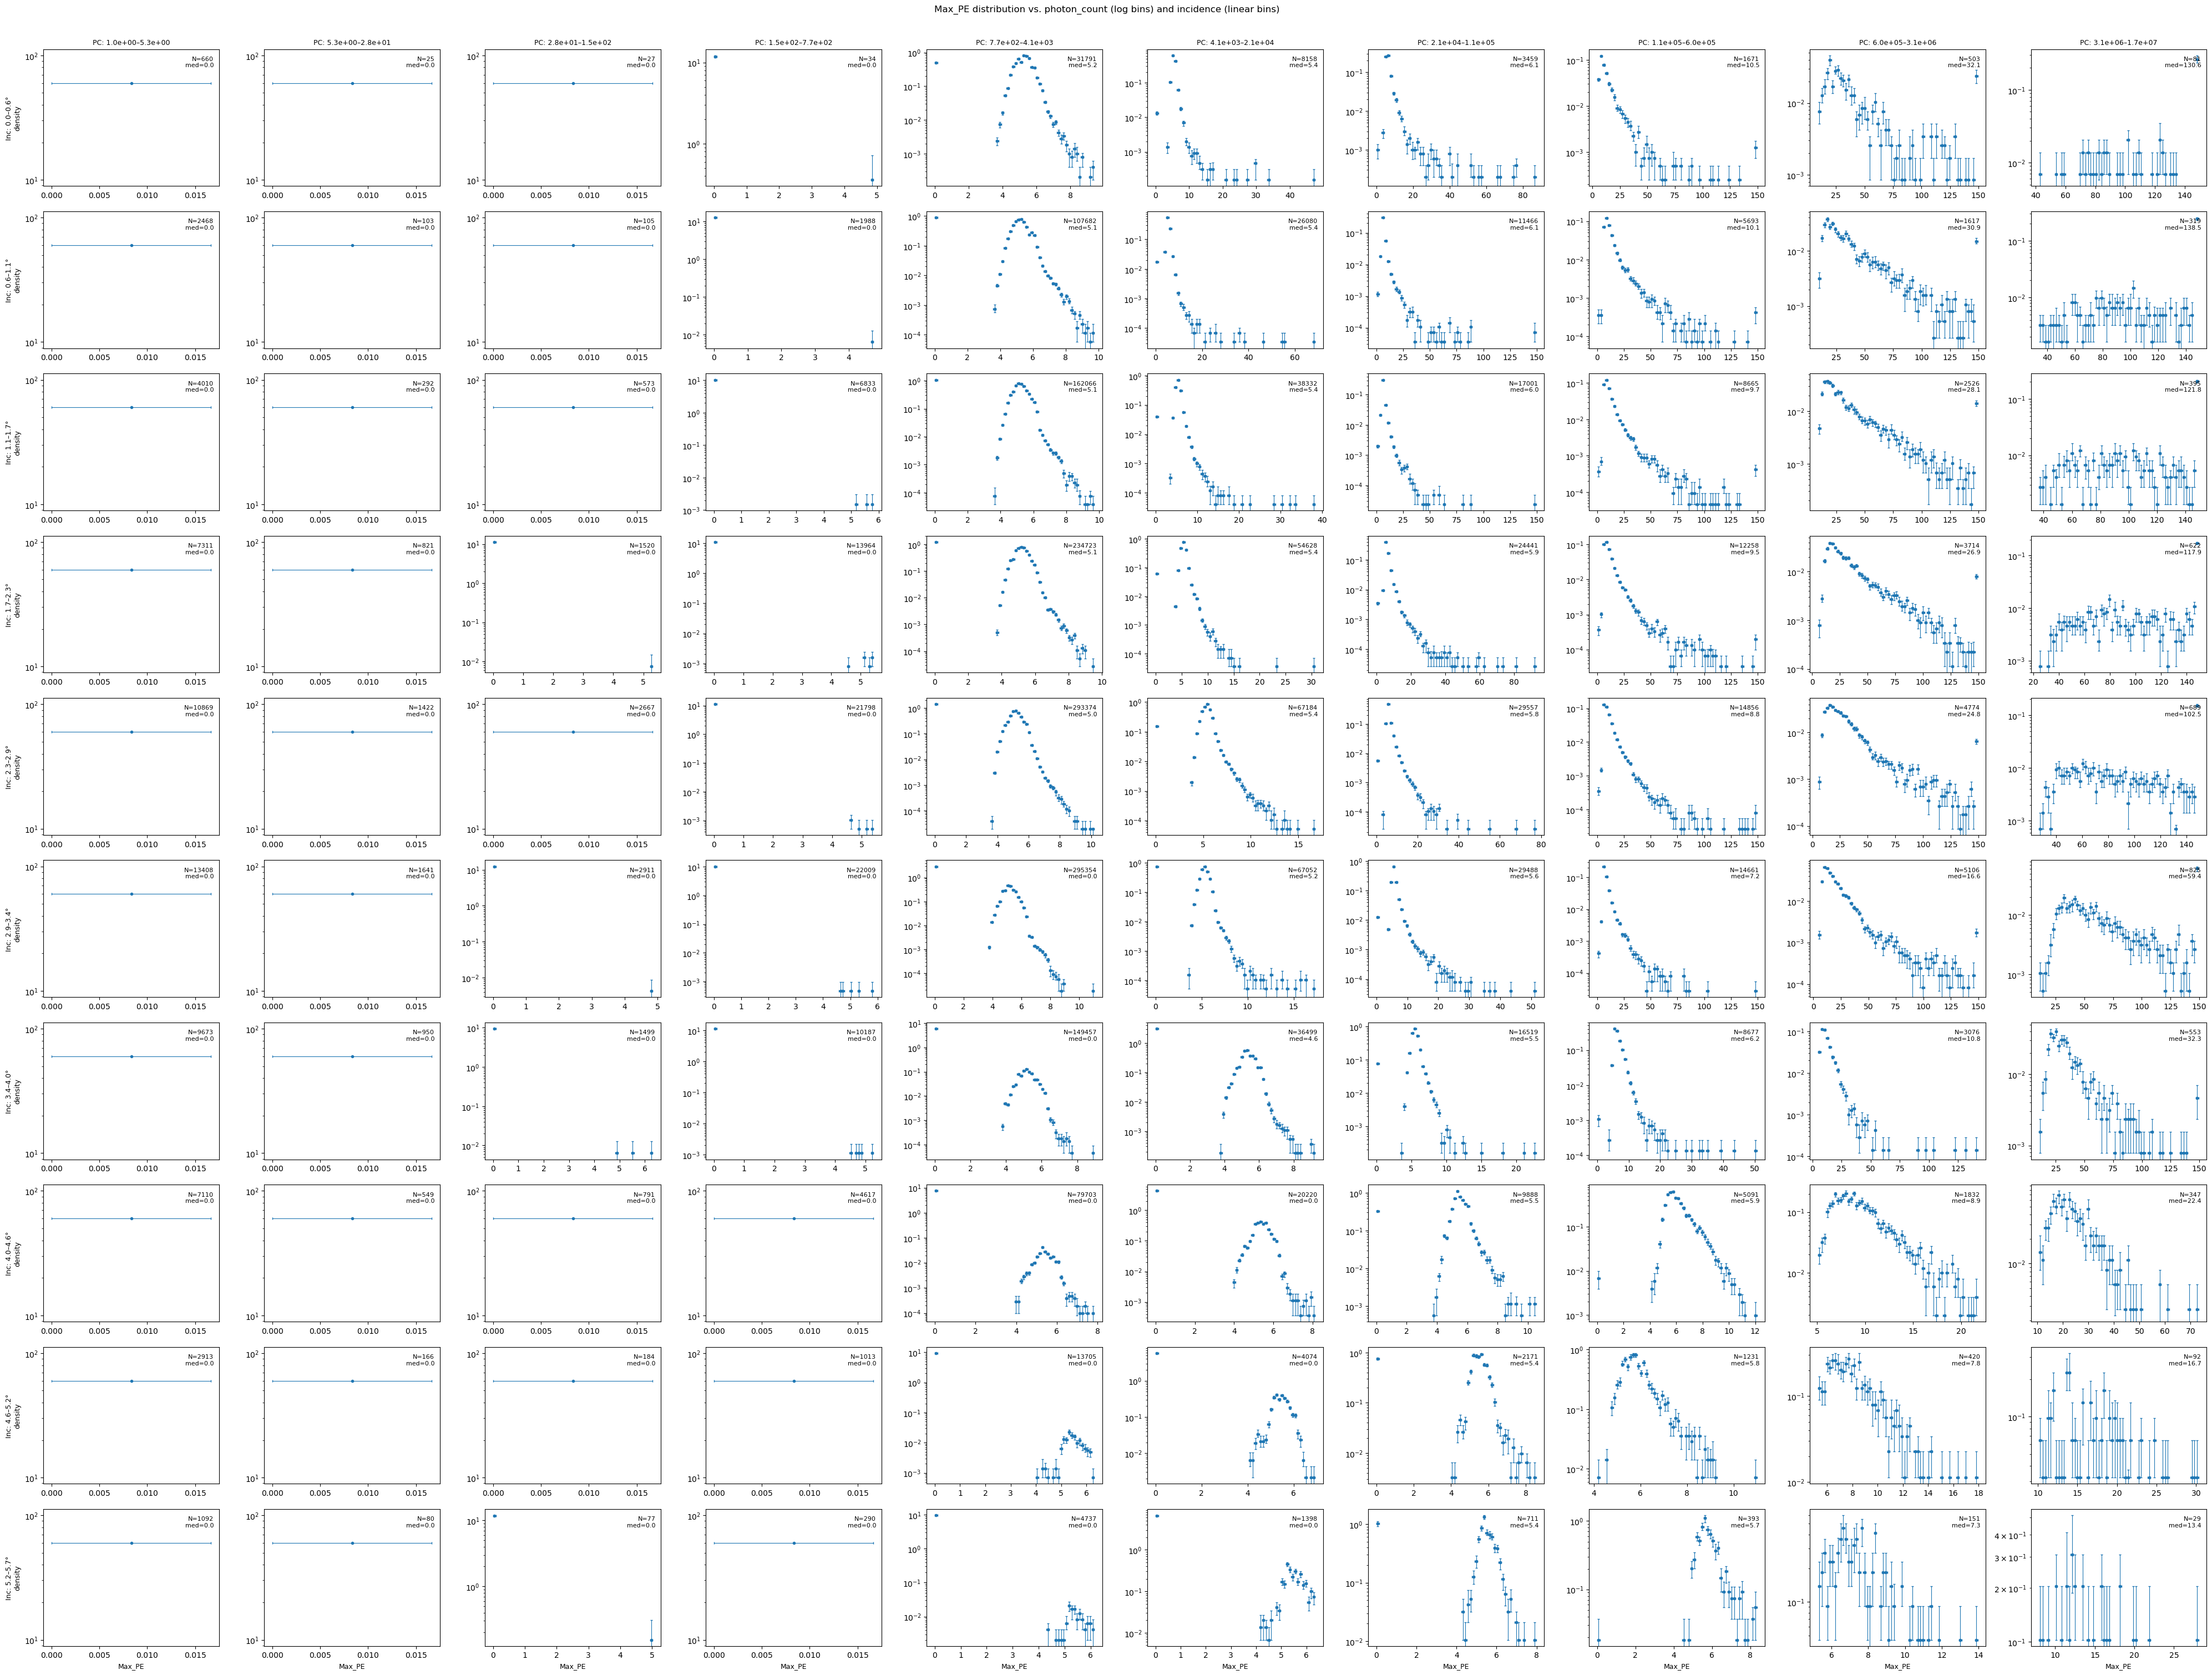

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Configuration ----------------
n_pc   = 10          # number of photon_count bins  -> columns (m)
n_inc  = 10         # number of incidence bins     -> rows (n)
n_bins = 60         # Max_PE histogram bins per panel
n_boot = 100
rng    = np.random.default_rng(42)

# ---------------- Bin edges --------------------
# Log bins for photon_count (only over positive values)
pc_pos = photon_count[(photon_count > 0) & np.isfinite(photon_count)]
pc_edges = np.logspace(np.log10(pc_pos.min()), np.log10(pc_pos.max()), n_pc + 1)

# Equal-width bins for incidence
inc_fin = Incidence[np.isfinite(Incidence)]
inc_edges = np.linspace(inc_fin.min(), inc_fin.max(), n_inc + 1)

# ---------------- Figure grid ------------------
fig, axes = plt.subplots(n_inc, n_pc,
                         figsize=(4 * n_pc, 3 * n_inc),
                         sharex=False, sharey=False)
axes = np.atleast_2d(axes)

for i in range(n_inc):            # rows: incidence
    for j in range(n_pc):         # cols: photon_count
        ax = axes[i, j]

        # --- Select data in this 2D cell ---
        sel = ((photon_count >= pc_edges[j]) & (photon_count < pc_edges[j + 1]) &
               (Incidence    >= inc_edges[i]) & (Incidence    < inc_edges[i + 1]))
        data = Max_PE[sel]
        data = data[np.isfinite(data)]
        N = data.size

        # --- Skip empty / too-sparse cells ---
        if N < 5:
            ax.text(0.5, 0.5, f"N={N}", ha='center', va='center',
                    transform=ax.transAxes, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            continue

        # --- Fixed-edge density histogram ---
        density, edges = np.histogram(data, bins=n_bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        widths  = np.diff(edges)

        # --- Bootstrap density replicas ---
        boot = np.empty((n_boot, len(centers)))
        for b in range(n_boot):
            sample = rng.choice(data, size=N, replace=True)
            boot[b], _ = np.histogram(sample, bins=edges, density=True)

        lo = np.percentile(boot, 16, axis=0)
        hi = np.percentile(boot, 84, axis=0)
        yerr = np.clip(np.vstack([density - lo, hi - density]), 0, None)

        nz = density > 0
        ax.errorbar(centers[nz], density[nz],
                    yerr=yerr[:, nz], xerr=widths[nz] / 2,
                    fmt='o', ms=3, capsize=1.5, color='C0', lw=0.8)
        ax.set_yscale("log")

        # --- Per-panel annotation ---
        ax.text(0.97, 0.95, f"N={N}\nmed={np.median(data):.1f}",
                ha='right', va='top', transform=ax.transAxes, fontsize=8)

        # --- Edge labels only on outer panels ---
        if i == 0:
            ax.set_title(f"PC: {pc_edges[j]:.1e}\u2013{pc_edges[j+1]:.1e}",
                         fontsize=9)
        if j == 0:
            ax.set_ylabel(f"Inc: {inc_edges[i]:.1f}\u2013{inc_edges[i+1]:.1f}\u00b0\n"
                          "density", fontsize=9)
        if i == n_inc - 1:
            ax.set_xlabel("Max_PE", fontsize=9)

fig.suptitle("Max_PE distribution vs. photon_count (log bins) and incidence (linear bins)",
             y=1.005, fontsize=12)
fig.tight_layout()
plt.show()
